# Análisis exploratorio de los datos

En este notebook se realiza un análisis exploratorio de los conjuntos de datos descargados de [PhysioNet](https://physionet.org/content/challenge-2019/1.0.0/), correspondientes al PhysioNet/Computing in Cardiology Challenge 2019.

El objetivo de este notebook es analizar la estructura, la calidad y la representatividad del conjunto de datos. Este análisis permitirá comprender mejor las variables empleadas, detectar posibles problemas y servir como base para la toma de decisiones en la etapa de preprocesamiento.



---

## 1. Carga y estructura inicial

Primero, montamos la carpeta el drive donde hemos subido las carpetas zip de los datos.

In [1]:
from google.colab import drive
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definimos las rutas en las que tenemos nuestros archivos. Comprobamos que los archivos existen.

In [2]:
DRIVE_DATA_PATH = Path("/content/drive/MyDrive/data")

ZIP_A_PATH = DRIVE_DATA_PATH / "training_setA.zip"
ZIP_B_PATH = DRIVE_DATA_PATH / "training_setB.zip"

LOCAL_RAW_PATH = Path("/content/data/raw")
LOCAL_RAW_PATH.mkdir(parents=True, exist_ok=True)

print("Existe A:", ZIP_A_PATH.exists())
print("Existe B:", ZIP_B_PATH.exists())

Existe A: True
Existe B: True


Copiamos los zips al notebook en la carpeta `/content` y los descomprimimos.

In [3]:
!cp "/content/drive/MyDrive/data/training_setA.zip" "/content/training_setA.zip"
!cp "/content/drive/MyDrive/data/training_setB.zip" "/content/training_setB.zip"

!rm -rf "/content/data/raw/training_setA"
!rm -rf "/content/data/raw/training_setB"

!mkdir -p "/content/data/raw"

!unzip -q "/content/training_setA.zip" -d "/content/data/raw"
!unzip -q "/content/training_setB.zip" -d "/content/data/raw"

Comprobamos que los archivos se han descomprimido correctamente.

In [4]:
SET_A_PATH = Path("/content/data/raw/training_setA")
SET_B_PATH = Path("/content/data/raw/training_setB")

files_A = sorted(SET_A_PATH.glob("*.psv"))
files_B = sorted(SET_B_PATH.glob("*.psv"))

print("Archivos en training_setA:", len(files_A))
print("Archivos en training_setB:", len(files_B))
print("Total de archivos:", len(files_A) + len(files_B))

Archivos en training_setA: 20336
Archivos en training_setB: 20000
Total de archivos: 40336


Cada archivo .psv de los directorios corresponde a información de un paciente y cada fila dentro del archivo es una medición horaria de dicho paciente. Por ello, se leen todos los archivos .psv, se añade una columna con el identificador del paciente y otra que identifica al hospital del que provienen los datos. Por último, se concatena toda la información en un único DataFrame.

La siguiente función permite leer todos los .psv de una carpeta y concatenarlos en un único DataFrame.

In [5]:
def load_psv_folder(folder_path, hospital_label):
    """
    Lee todos los archivos .psv de una carpeta y los concatena en un único DataFrame.

    Cada archivo corresponde a un paciente.
    Cada fila corresponde a un instante temporal del paciente.
    """
    folder_path = Path(folder_path)
    files = sorted(folder_path.glob("*.psv"))

    dataframes = []

    for file in tqdm(files, desc=f"Cargando conjunto {hospital_label}"):
        df_patient = pd.read_csv(file, sep="|")

        # Identificador del paciente a partir del nombre del archivo
        df_patient["PatientID"] = file.stem

        # Conjunto u hospital de procedencia
        df_patient["Hospital"] = hospital_label

        # Índice temporal dentro del archivo
        df_patient["TimeStep"] = range(1, len(df_patient) + 1)
        id_cols = ["PatientID", "Hospital", "TimeStep"]

        # Reordenamos las columnas para que estén más organizadas
        other_cols = [col for col in df_patient.columns if col not in id_cols]
        df_patient = df_patient[id_cols + other_cols]

        dataframes.append(df_patient)

    return pd.concat(dataframes, ignore_index=True)

Cargamos ambos conjuntos y concatenamos todos los datos en un único DataFrame.

In [6]:
df_A = load_psv_folder(SET_A_PATH, "A")
df_B = load_psv_folder(SET_B_PATH, "B")

df = pd.concat([df_A, df_B], ignore_index=True)



Cargando conjunto A:   0%|          | 0/20336 [00:00<?, ?it/s]

Cargando conjunto B:   0%|          | 0/20000 [00:00<?, ?it/s]

Guardamos el DataFrame como Parquet con el objetivo de que sea más fácil cargarlo en futuros notebooks

In [7]:
!pip install pyarrow -q

In [8]:
PROCESSED_PATH = Path("/content/drive/MyDrive/data/processed")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

PARQUET_PATH = PROCESSED_PATH / "physionet_sepsis_raw_combined.parquet"

df.to_parquet(PARQUET_PATH, index=False)

print("Archivo guardado en:", PARQUET_PATH)

Archivo guardado en: /content/drive/MyDrive/data/processed/physionet_sepsis_raw_combined.parquet


Hacemos algunas comprobaciones para ver que el DataFrame se ha creado correctamente.

In [9]:
print("Dimensiones de A:", df_A.shape)
print("Dimensiones de B:", df_B.shape)
print("Dimensiones totales:", df.shape)

Dimensiones de A: (790215, 44)
Dimensiones de B: (761995, 44)
Dimensiones totales: (1552210, 44)


Finalmente, hagamos un análisis inicial de la estructura del conjunto de datos.

In [10]:
print("Número total de pacientes:", df["PatientID"].nunique())
print("Número total de registros horarios:", len(df))
print("Número de columnas:", df.shape[1])
print("Nombres de las columnas:", df.columns.tolist())
print("Tipos de datos de las columnas:", df.dtypes)

print("\nPacientes por conjunto:")
print(df.groupby("Hospital")["PatientID"].nunique())

print("\nRegistros por conjunto:")
print(df["Hospital"].value_counts())



Número total de pacientes: 40336
Número total de registros horarios: 1552210
Número de columnas: 44
Nombres de las columnas: ['PatientID', 'Hospital', 'TimeStep', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']
Tipos de datos de las columnas: PatientID            object
Hospital             object
TimeStep              int64
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2             

Como podemos ver, contamos con datos de 40336 pacientes y un total de 1552210 registros horarios. Por otra parte, el DataFrame final contiene 44 columnas: las variables originales del conjunto de datos, junto con la variable objetivo SepsisLabel, y tres columnas auxiliares añadidas durante la carga: PatientID, Hospital y TimeStep.

Veamos cómo se ve un archivo de un paciente concreto.

In [11]:
# Escogemos por ejemplo el paciente con identificador "p000002"
df_patient = df[df["PatientID"] == "p000002"]
df_patient

,PatientID,Hospital,TimeStep,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
54,p000002,A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,1,0
55,p000002,A,2,61.0,99.0,36.44,124.0,65.0,43.0,17.5,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,2,0
56,p000002,A,3,64.0,98.0,NaN,125.0,64.0,41.0,27.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,3,0
57,p000002,A,4,56.0,100.0,NaN,123.0,65.0,41.0,9.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,4,0
58,p000002,A,5,66.0,99.0,NaN,120.0,67.0,43.0,23.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,5,0
59,p000002,A,6,94.0,100.0,36.22,194.0,116.0,66.0,14.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,6,0
60,p000002,A,7,58.0,99.0,NaN,133.0,68.0,43.0,13.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,7,0
61,p000002,A,8,57.0,100.0,NaN,118.0,62.0,37.0,18.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,8,0
62,p000002,A,9,62.0,100.0,NaN,126.0,66.0,37.0,12.0,...,NaN,NaN,NaN,75.91,0,0.0,1.0,-98.6,9,0
63,p000002,A,10,58.0,95.0,36.11,143.0,77.0,47.0,11.0,...,11.0,NaN,158.0,75.91,0,0.0,1.0,-98.6,10,0


In [12]:
print(f"Paciente: p000002")
print(f"Número de registros temporales: {len(df_patient)}")
print(f"Primer instante temporal: {df_patient['TimeStep'].min()}")
print(f"Último instante temporal: {df_patient['TimeStep'].max()}")

Paciente: p000002
Número de registros temporales: 23
Primer instante temporal: 1
Último instante temporal: 23


Podemos observar que cada fila corresponde con un instante temporal. Por otra parte, notamos que la variable Age y Gender se mantienen constantes y que la variable objetivo está definida por filas, es decir, en cada instante de tiempo indica si el paciente tenía sepsis (valor 1) o no (valor 0).

Veamos ahora algún paciente con sepsis.

In [13]:
id_sepsis_patient=df[df["SepsisLabel"]==1].iloc[0]['PatientID']
df[df["PatientID"]==id_sepsis_patient]

,PatientID,Hospital,TimeStep,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
304,p000009,A,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,1,0
305,p000009,A,2,117.0,99.0,NaN,116.0,97.0,81.0,20.0,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,2,0
306,p000009,A,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,8.9,124.0,64.0,27.92,1,NaN,NaN,-0.03,3,0
307,p000009,A,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.9,180.0,114.0,27.92,1,NaN,NaN,-0.03,4,0
308,p000009,A,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557,p000009,A,254,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,254,1
558,p000009,A,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,255,1
559,p000009,A,256,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,256,1
560,p000009,A,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,27.92,1,NaN,NaN,-0.03,257,1


In [14]:
print(f"Paciente: {id_sepsis_patient}")
print(f"Número de registros temporales: {len(df[df['PatientID'] == id_sepsis_patient])}")
print(f"Primer instante temporal en el que se diagnostica sepsis: {df[(df['PatientID'] == id_sepsis_patient) & (df['SepsisLabel']==1)]['TimeStep'].min()}")


Paciente: p000009
Número de registros temporales: 258
Primer instante temporal en el que se diagnostica sepsis: 249


# 2. Estructura temporal

En este apartado vamos a estudiar la estructura temporal del conjunto de datos.

## 2.1. Análisis del número de registros por paciente

In [15]:
# Agrupamos, contamos y reseteamos el índice para mantener el formato de tabla
df_resumen = df.groupby('PatientID').size().reset_index(name='NumRegistrosTemporales')
df_resumen['NumRegistrosTemporales'].max()
print(df_resumen)


      PatientID  NumRegistrosTemporales
0       p000001                      54
1       p000002                      23
2       p000003                      48
3       p000004                      29
4       p000005                      48
...         ...                     ...
40331   p119996                      48
40332   p119997                      25
40333   p119998                      49
40334   p119999                      20
40335   p120000                      35

[40336 rows x 2 columns]


In [16]:
print("Número máximo de registros temporales para un mismo paciente:", df_resumen['NumRegistrosTemporales'].max())
print("Número mínimo de registros temporales para un mismo paciente:", df_resumen['NumRegistrosTemporales'].min())
print("Número medio de registros temporales por paciente:", df_resumen['NumRegistrosTemporales'].mean())
print("Número mediano de registros temporales por paciente:", df_resumen['NumRegistrosTemporales'].median())

Número máximo de registros temporales para un mismo paciente: 336
Número mínimo de registros temporales para un mismo paciente: 8
Número medio de registros temporales por paciente: 38.48200119000396
Número mediano de registros temporales por paciente: 38.0


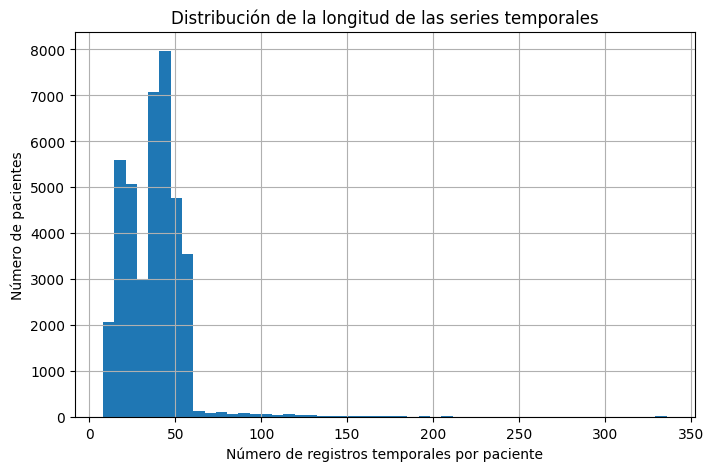

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_resumen["NumRegistrosTemporales"], bins=50)
plt.xlabel("Número de registros temporales por paciente")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la longitud de las series temporales")
plt.grid(True)
plt.show()

Podemos ver que el número de registros para cada paciente es variable. La mayoría de pacientes presentan entre 20 y 55 registros aproximadamente. La media es de 38.48 registros por paciente y la mediana de 38, por lo que el valor típico está alrededor de 38.
Por otra parte, hay pacientes con estancias muy cortas, con un mínimo de 8 registros, y otros con estancias muy largas, con un máximo de 336 registros.
Por último, la distribución está sesgada hacia la derecha porque hay pocos pacientes que tengan muchos registros temporales.


Centrémonos ahora en pacientes que tengan muchos o pocos registros.

In [18]:
# Miramos los pacientes cuyo número de registros está por debajo del percentil 1
df_pocosRegistros=df_resumen[df_resumen["NumRegistrosTemporales"] < df_resumen["NumRegistrosTemporales"].quantile(0.01)]
df_pocosRegistros

,PatientID,NumRegistrosTemporales
57,p000058,8
210,p000211,8
402,p000403,8
523,p000524,8
864,p000865,8
...,...,...
39784,p119449,8
39861,p119526,8
40100,p119765,8
40189,p119854,8


In [19]:
# Miramos los pacientes cuyo número de registros está por encima del percentil 99
df_muchosRegistros=df_resumen[df_resumen["NumRegistrosTemporales"] > df_resumen["NumRegistrosTemporales"].quantile(0.99)]
df_muchosRegistros

,PatientID,NumRegistrosTemporales
8,p000009,258
17,p000018,134
356,p000357,147
372,p000373,148
400,p000401,214
...,...,...
40084,p119749,169
40086,p119751,140
40095,p119760,145
40126,p119791,161


In [20]:
porcent=(len(df_muchosRegistros)+len(df_pocosRegistros))*100/df_resumen.shape[0]
print("El número de pacientes con muchos registros o muy pocos registros supone el siguiente porcentaje respecto al total:", porcent)

El número de pacientes con muchos registros o muy pocos registros supone el siguiente porcentaje respecto al total: 1.8122768742562476


Vemos que tanto el número de pacientes con pocos registros como el número de pacientes con muchos registros es pequeño en comparación con el número de pacientes total, ya que representan tan solo el 1.81% de los pacientes. Esto es relevante pues pacientes con pocos registros aportan poca información temporal, lo que hace que sea difícil extraer patrones fiables a partir de ellos. Por otra parte, los pacientes con un número muy alto de registros aportan muchas más filas que otros y pueden influir más en el entrenamiento, afectando al análisis de los datos y las estadísticas globales si no se manejan adecuadamente. Por ello, vamos a analizar si existe una relación entre el número de registros que se tiene de un paciente y si tiene o no sepsis.

In [21]:
df_resumen = df.groupby(["PatientID", "Hospital"]).agg(
    TotalFilas=("PatientID", "size"),
    TieneSepsis=("SepsisLabel", "max")
).reset_index()

df_resumen.groupby("TieneSepsis")["TotalFilas"].agg(
    pacientes="count",
    media="mean",
    std="std",
    mediana="median",
    minimo="min",
    maximo="max"
)

,pacientes,media,std,mediana,minimo,maximo
TieneSepsis,,,,,,
0,37404,36.889103,15.84266,39.0,8,336
1,2932,58.802865,59.18483,37.5,8,336


Los pacientes con sepsis presentan una media mayor de registros temporales, aunque la mediana es similar entre ambos grupos. Esto indica que la diferencia parece deberse principalmente a una mayor dispersión y a la presencia de casos con muchas observaciones.

## 2.2. Análisis de la variable `ICULOS`

A continuación, vamos a analizar la distribución de la variable del conjunto de datos llamada ICULOS, y que representa el tiempo de estancia, medido en horas, del paciente en la UCI desde su ingreso en dicha unidad.

In [22]:
print("Número máximo de horas en UCI:", df['ICULOS'].max())
print("Número mínimo de horas en UCI:", df['ICULOS'].min())
print("Media de estancia en horas en UCI:", df['ICULOS'].mean())
print("Mediana de estancia en horas en UCI:", df['ICULOS'].median())

Número máximo de horas en UCI: 336
Número mínimo de horas en UCI: 1
Media de estancia en horas en UCI: 26.994992301299437
Mediana de estancia en horas en UCI: 21.0


Vemos que también las horas de estancia en UCI varían mucho de un paciente a otro, siendo el mínimo 1 hora y el máximo 336 horas. La mediana de 21 horas indica que la mitad de los registros corresponden a valores de ICULOS iguales o inferiores a 21, mientras que la media se ve incrementada por la presencia de estancias prolongadas.

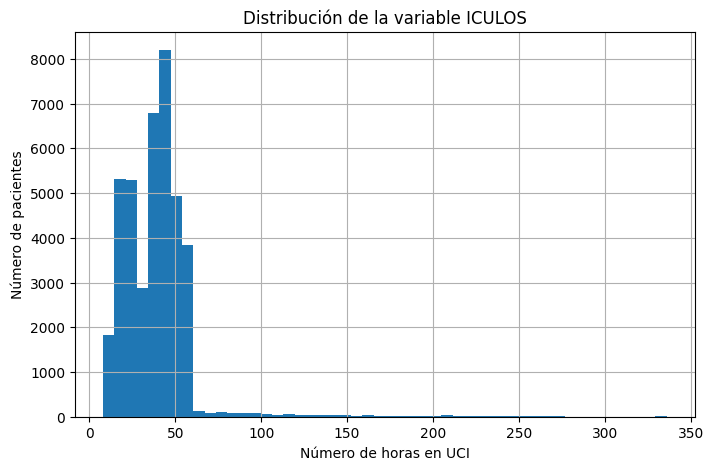

In [23]:
import matplotlib.pyplot as plt

# Guardamos un DataFrame en el que a cada paciente se le asocia con el valor de ICULOS máximo que alcanza
df_iculos = df.groupby(["PatientID", "Hospital"]).agg(
    ICULOS_max=("ICULOS", "max"),
    TieneSepsis=("SepsisLabel", "max")
).reset_index()


plt.figure(figsize=(8, 5))
plt.hist(df_iculos["ICULOS_max"], bins=50)
plt.xlabel("Número de horas en UCI")
plt.ylabel("Número de pacientes")
plt.title("Distribución de la variable ICULOS")
plt.grid(True)
plt.show()

Podemos ver que la distribución está bastante sesgada hacia la derecha, lo que coincide con lo que vimos en la distribución de registros por pacientes. Esto indica que, aunque la mayoría de los pacientes tuvieron una estancia en UCI de menos de 30 horas, algunos de ellos tuvieron una estancia mucho más larga.

Veamos si existe una relación entre estancias largas en UCI y sepsis.

In [24]:
# Vemos los estadísticos de ICULOS_max
df_iculos.groupby("TieneSepsis")["ICULOS_max"].agg(
    pacientes="count",
    media="mean",
    mediana="median",
    minimo="min",
    maximo="max"
)

,pacientes,media,mediana,minimo,maximo
TieneSepsis,,,,,
0,37404,37.410437,39.0,8,336
1,2932,59.417462,38.0,8,336


/tmp/ipykernel_9850/2262499295.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data_sin_sepsis, data_con_sepsis], labels=["Sin sepsis", "Con sepsis"])


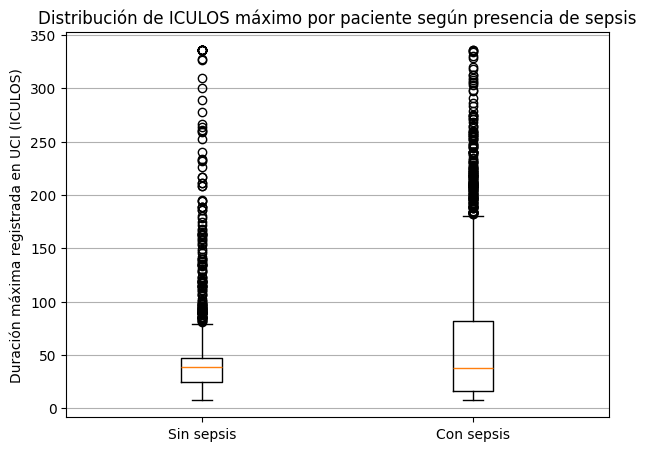

In [25]:
import matplotlib.pyplot as plt

data_sin_sepsis = df_iculos[df_iculos["TieneSepsis"] == 0]["ICULOS_max"]
data_con_sepsis = df_iculos[df_iculos["TieneSepsis"] == 1]["ICULOS_max"]

plt.figure(figsize=(7, 5))
plt.boxplot([data_sin_sepsis, data_con_sepsis], labels=["Sin sepsis", "Con sepsis"])
plt.ylabel("Duración máxima registrada en UCI (ICULOS)")
plt.title("Distribución de ICULOS máximo por paciente según presencia de sepsis")
plt.grid(axis="y")
plt.show()

In [26]:
resumen_iculos = df_iculos.groupby("TieneSepsis")["ICULOS_max"].agg(
    pacientes="count",
    media="mean",
    mediana="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
    maximo="max"
).reset_index()

resumen_iculos["TieneSepsis"] = resumen_iculos["TieneSepsis"].map({
    0: "Sin sepsis",
    1: "Con sepsis"
})

resumen_iculos

,TieneSepsis,pacientes,media,mediana,q1,q3,maximo
0,Sin sepsis,37404,37.410437,39.0,25.0,47.0,336
1,Con sepsis,2932,59.417462,38.0,16.0,82.0,336


El boxplot muestra la distribución de la duración máxima registrada en UCI, medida mediante `ICULOS`, diferenciando entre pacientes con y sin sepsis. Aunque la mediana es similar entre ambos grupos, los pacientes con sepsis presentan una mayor dispersión y un mayor número de estancias prolongadas. Esta diferencia nos indica que la estancia de los pacientes con sepsis tiende a ser más variable y, en algunos casos, más prolongada.

# 3. Análisis de la variable objetivo `SepsisLabel`

En este apartado vamos a realizar un análisis de la variable objetivo `SepsisLabel` con el objetivo de estudiar la representatividad que hay en nuestros datos de cada clase.

## 3.1. Desbalance a nivel de registro y de paciente

In [27]:
n_total = len(df)
n_pos = (df["SepsisLabel"] == 1).sum()
n_neg = (df["SepsisLabel"] == 0).sum()

print(f"Número total de registros: {n_total}")
print(f"Número de registros con SepsisLabel = 1: {n_pos}")
print(f"Número de registros con SepsisLabel = 0: {n_neg}")
print(f"Porcentaje de registros positivos: {n_pos / n_total * 100:.2f}%")
print(f"Porcentaje de registros negativos: {n_neg / n_total * 100:.2f}%")

Número total de registros: 1552210
Número de registros con SepsisLabel = 1: 27916
Número de registros con SepsisLabel = 0: 1524294
Porcentaje de registros positivos: 1.80%
Porcentaje de registros negativos: 98.20%


Se observa un fuerte desbalance de clases a nivel de registro temporal: únicamente el 1,8% de las filas presentan `SepsisLabel = 1`, mientras que la gran mayoría corresponden a registros sin sepsis. Este desbalance es relevante porque puede afectar tanto al entrenamiento como a la evaluación de los modelos. Por ello, las decisiones posteriores de preprocesamiento, particionado y selección de métricas deberán tener en cuenta la baja representatividad de la clase positiva.

A continuación, hacemos un análisis similar pero esta vez a nivel de paciente.


In [28]:
# A cada paciente se le asigna 0 si no presenta sepsis en ninguno de sus registros temporales
# y 1 si presenta sepsis en alguno de sus registros temporales
df_paciente_sepsis = df.groupby("PatientID")["SepsisLabel"].max().reset_index()
n_total = len(df_paciente_sepsis)
n_pos = (df_paciente_sepsis["SepsisLabel"] == 1).sum()
n_neg = (df_paciente_sepsis["SepsisLabel"] == 0).sum()

print(f"Número total de pacientes: {n_total}")
print(f"Número de pacientes con SepsisLabel = 1: {n_pos}")
print(f"Número de pacientes con SepsisLabel = 0: {n_neg}")
print(f"Porcentaje de pacientes positivos: {n_pos / n_total * 100:.2f}%")
print(f"Porcentaje de pacientes negativos: {n_neg / n_total * 100:.2f}%")

Número total de pacientes: 40336
Número de pacientes con SepsisLabel = 1: 2932
Número de pacientes con SepsisLabel = 0: 37404
Porcentaje de pacientes positivos: 7.27%
Porcentaje de pacientes negativos: 92.73%


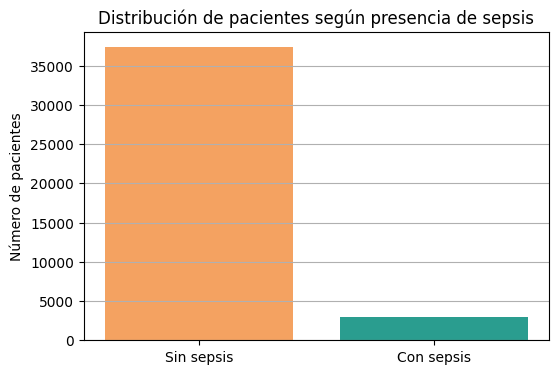

In [29]:
import matplotlib.pyplot as plt

conteo_pacientes = df_paciente_sepsis["SepsisLabel"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Sin sepsis", "Con sepsis"], conteo_pacientes.values, color=['#F4A261', '#2A9D8F'])
plt.ylabel("Número de pacientes")
plt.title("Distribución de pacientes según presencia de sepsis")
plt.grid(axis="y")
plt.show()

A nivel de paciente también se observa un claro desbalance entre clases: solo el 7,27% de los pacientes presentan al menos un registro con `SepsisLabel = 1`. No obstante, este porcentaje es superior al observado a nivel de registro temporal, donde los positivos representaban únicamente el 1,80% de las filas. Esta diferencia se debe a que un mismo paciente puede desarrollar sepsis en un momento concreto de su estancia, sin que todos sus registros temporales estén etiquetados como positivos.

Este resultado indica que el problema presenta **desbalance tanto a nivel de paciente como a nivel de registro**, por lo que será necesario tenerlo en cuenta tanto en el particionado de los datos, como en la selección de métricas y el entrenamiento de los modelos.

## 3.2. Diferencias entre hospitales

Veamos ahora si existe alguna diferencia clara entre los pacientes cuyos datos provienen del hospital A y los que provienen del hospital B.

In [30]:
df_pacientes = df.groupby(["PatientID", "Hospital"]).agg(
    TieneSepsis=("SepsisLabel", "max")
).reset_index()

resumen_hospital = df_pacientes.groupby("Hospital")["TieneSepsis"].agg(
    total_pacientes="count",
    pacientes_con_sepsis="sum"
)

resumen_hospital["pacientes_sin_sepsis"] = (
    resumen_hospital["total_pacientes"] - resumen_hospital["pacientes_con_sepsis"]
)

resumen_hospital["porcentaje_con_sepsis"] = (
    resumen_hospital["pacientes_con_sepsis"] / resumen_hospital["total_pacientes"] * 100
)

resumen_hospital["porcentaje_sin_sepsis"] = (
    resumen_hospital["pacientes_sin_sepsis"] / resumen_hospital["total_pacientes"] * 100
)
resumen_hospital = resumen_hospital.rename(columns={
    "total_pacientes": "Total pacientes",
    "pacientes_con_sepsis": "Pacientes con sepsis",
    "pacientes_sin_sepsis": "Pacientes sin sepsis",
    "porcentaje_con_sepsis": "% con sepsis",
    "porcentaje_sin_sepsis": "% sin sepsis"
})

resumen_hospital

,Total pacientes,Pacientes con sepsis,Pacientes sin sepsis,% con sepsis,% sin sepsis
Hospital,,,,,
A,20336,1790,18546,8.802124,91.197876
B,20000,1142,18858,5.710000,94.290000


Vemos que ambos presentan un claro desbalance entre pacientes con y sin sepsis. No obstante, se observa una diferencia algo menos pronunciada en el hospital A, que presenta un 8.8% de pacientes con sepsis, mientras que el hospital B solo presenta un 5.71%. Por tanto, observamos que la proporción de casos positivos no es homogénea entre hospitales. Esta diferencia deberá tenerse en cuenta tanto para realizar el particionado de los datos como para evaluar la capacidad de generalización del modelo, ya que la distribución de la variable objetivo varía entre los dos conjuntos.

## 3.3. Evolución temporal de la variable objetivo

In [31]:
# Creamos un DataFrame que agrupando por por paciente y hospital
df_label_paciente = df.groupby(["PatientID", "Hospital"]).agg(
    n_registros=("SepsisLabel", "size"), # Número de registros temporales para cada paciente
    min_label=("SepsisLabel", "min"), # Valor mínimo de SepsisLabel alcanzado
    max_label=("SepsisLabel", "max"), # Valor máximo de SepsisLabel alcanzado
    n_positivos=("SepsisLabel", "sum"), # Número de registros en el que SepsisLabel es positivo
    primer_timestep=("TimeStep", "min"),
    ultimo_timestep=("TimeStep", "max"),
    primer_iculos=("ICULOS", "min"), # Mínima marca de tiempo en UCI
    ultimo_iculos=("ICULOS", "max") # Máxima marca de tiempo en UCI
).reset_index()

df_label_paciente["TieneSepsis"] = df_label_paciente["max_label"]

df_label_paciente.head()



,PatientID,Hospital,n_registros,min_label,max_label,n_positivos,primer_timestep,ultimo_timestep,primer_iculos,ultimo_iculos,TieneSepsis
0,p000001,A,54,0,0,0,1,54,1,54,0
1,p000002,A,23,0,0,0,1,23,1,23,0
2,p000003,A,48,0,0,0,1,48,1,48,0
3,p000004,A,29,0,0,0,1,29,1,29,0
4,p000005,A,48,0,0,0,1,48,2,49,0


In [32]:
def clasificar_evolucion(row):
    if row["min_label"] == 0 and row["max_label"] == 0:
        return "Siempre negativo"
    elif row["min_label"] == 1 and row["max_label"] == 1:
        return "Siempre positivo"
    else:
        return "Cambio 0-1"

df_label_paciente["TipoEvolucion"] = df_label_paciente.apply(clasificar_evolucion, axis=1)

resumen_evolucion = df_label_paciente["TipoEvolucion"].value_counts().to_frame("Pacientes")
resumen_evolucion["Porcentaje"] = (
    df_label_paciente["TipoEvolucion"].value_counts(normalize=True) * 100
).round(2)

resumen_evolucion

,Pacientes,Porcentaje
TipoEvolucion,,
Siempre negativo,37404,92.73
Cambio 0-1,2506,6.21
Siempre positivo,426,1.06


Podemos ver que la mayoría de pacientes no presentan sepsis en ningún momento. Por otra parte, dentro de los pacientes que presentan sepsis, la mayoría de ellos no presentan sepsis inicialmente pero sí a partir de un instante determinado. Por otra parte, los pacientes que desde el primer registro disponible ya aparecen etiquetados con sepsis representan un porcentaje muy bajo, cercano al 1%

In [33]:
primer_positivo = (
    df[df["SepsisLabel"] == 1]
    .groupby(["PatientID", "Hospital"])
    .agg(
        PrimerTimeStepPositivo=("TimeStep", "min"),
        PrimerICULOSPositivo=("ICULOS", "min")
    )
    .reset_index()
)

pacientes_con_sepsis = df_label_paciente[df_label_paciente["TieneSepsis"] == 1].merge(
    primer_positivo,
    on=["PatientID", "Hospital"],
    how="left"
)

pacientes_con_sepsis[["PrimerTimeStepPositivo", "PrimerICULOSPositivo"]].describe()

,PrimerTimeStepPositivo,PrimerICULOSPositivo
count,2932.000000,2932.000000
mean,50.281719,50.896317
std,59.104795,59.363675
min,1.000000,1.000000
25%,6.750000,7.000000
50%,29.000000,29.000000
75%,72.000000,73.000000
max,331.000000,331.000000


La media del primer registro positivo se sitúa alrededor del instante 50, aunque la desviación típica es elevada. Por ello, la mediana resulta más representativa: en la mitad de los pacientes con sepsis, la primera etiqueta positiva aparece en torno al registro 29, aproximadamente a las 29 horas de estancia en UCI.

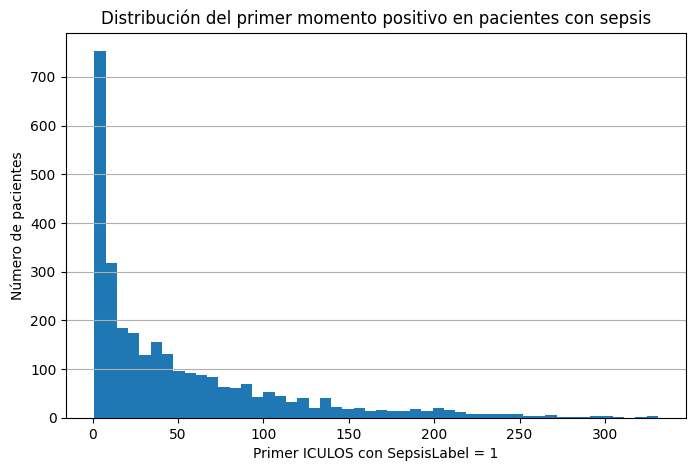

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(pacientes_con_sepsis["PrimerICULOSPositivo"], bins=50)
plt.xlabel("Primer ICULOS con SepsisLabel = 1")
plt.ylabel("Número de pacientes")
plt.title("Distribución del primer momento positivo en pacientes con sepsis")
plt.grid(axis="y")
plt.show()

Con el histograma podemos ver más claramente que la distribución está claramente sesgada hacia la derecha, pues la mayoría de pacientes presentan sepsis a las pocas horas de estancia en la UCI (valor bajo de ICULOS) pero también existen algunos que la presentan pasadas las 300 horas.

El desbalance de clases observado tiene implicaciones directas en el entrenamiento y la evaluación de los modelos. Por este motivo, la exactitud global no resulta suficiente para evaluar el rendimiento, ya que un modelo podría obtener valores elevados simplemente favoreciendo la clase mayoritaria. En consecuencia, en la evaluación se considerarán métricas más adecuadas para problemas desbalanceados, como AUROC, AUPRC, sensibilidad, especificidad, recall y F1-score. Además, durante el entrenamiento se valorarán estrategias como la ponderación de clases, el ajuste del umbral de decisión o técnicas de muestreo.

# 4. Comparación hospital A y hospital B

En este apartado se hace una comparación entre los datos obtenidos del hospital A y del hospital B con el objetivo de decidir si es mejor analizar cada conjunto de datos por separado o de forma conjunta.

In [35]:
# Resumen a nivel de paciente y hospital
df_paciente_hospital = df.groupby(["PatientID", "Hospital"]).agg(
    TieneSepsis=("SepsisLabel", "max"),
    ICULOS_max=("ICULOS", "max"),
    NumRegistros=("PatientID", "size")
).reset_index()

# Resumen general por hospital
resumen_hospital = df_paciente_hospital.groupby("Hospital").agg(
    pacientes=("PatientID", "count"),
    pacientes_con_sepsis=("TieneSepsis", "sum"),
    media_iculos=("ICULOS_max", "mean"),
    mediana_iculos=("ICULOS_max", "median"),
    media_registros=("NumRegistros", "mean"),
    mediana_registros=("NumRegistros", "median")
)

# Añadimos registros horarios por hospital
registros_hospital = df.groupby("Hospital").size().rename("registros_horarios")

resumen_hospital = resumen_hospital.join(registros_hospital)

# Porcentaje de pacientes con sepsis
resumen_hospital["porcentaje_sepsis"] = (
    resumen_hospital["pacientes_con_sepsis"] / resumen_hospital["pacientes"] * 100
)

# Reordenar columnas y redondear
resumen_hospital = resumen_hospital[
    [
        "pacientes",
        "registros_horarios",
        "pacientes_con_sepsis",
        "porcentaje_sepsis",
        "media_iculos",
        "mediana_iculos",
        "media_registros",
        "mediana_registros"
    ]
].round(2)

resumen_hospital

,pacientes,registros_horarios,pacientes_con_sepsis,porcentaje_sepsis,media_iculos,mediana_iculos,media_registros,mediana_registros
Hospital,,,,,,,,
A,20336,790215,1790,8.80,39.77,40.0,38.86,39.0
B,20000,761995,1142,5.71,38.23,38.0,38.10,38.0


Vemos que no existe una diferencia demasiado significativa a nivel de cantidad de información que se obtiene de cada uno de los hospitales.

In [36]:
# Columnas auxiliares que no interesa incluir en el análisis de ausentes
cols_aux = ["PatientID", "Hospital", "TimeStep"]

# Porcentaje de valores ausentes por variable y hospital
missing_by_hospital = (
    df.drop(columns=cols_aux)
    .groupby(df["Hospital"])
    .apply(lambda x: x.isna().mean() * 100)
    .T
)

missing_by_hospital["diferencia_abs"] = (
    missing_by_hospital["A"] - missing_by_hospital["B"]
).abs()

# Variables con mayor diferencia de ausentes entre hospitales
missing_by_hospital.sort_values("diferencia_abs", ascending=False).head(10).round(2)

Hospital,A,B,diferencia_abs
DBP,48.13,13.94,34.18
Unit2,48.87,29.63,19.24
Unit1,48.87,29.63,19.24
FiO2,85.81,97.74,11.93
Resp,9.78,21.14,11.36
BaseExcess,89.57,99.77,10.19
Glucose,87.77,77.84,9.93
pH,88.53,97.77,9.24
HCO3,91.95,99.81,7.87
Chloride,91.68,99.38,7.71


Vemos que el porcentaje de valores ausentes no es igual en los dos hospitales y que, de hecho, la diferencia es bastante grande para algunas variables específicas. En particular, la mayor diferencia se observa en `DBP`, con un 48,13% de valores ausentes en el hospital A frente a un 13,94% en el hospital B.

Estos resultados indican que la procedencia hospitalaria puede influir en la disponibilidad de determinadas mediciones. Por tanto, en el preprocesamiento será necesario considerar no solo el porcentaje global de valores ausentes, sino también posibles diferencias entre hospitales.


In [37]:
variables_clave = ["HR", "O2Sat", "Temp", "MAP", "Resp", "Lactate", "Creatinine", "WBC", "Platelets", "Age"]

medianas_hospital = df.groupby("Hospital")[variables_clave].median()

# Vemos la diferencia entre las medianas de ambos conjuntos para las variables clave
diferencias_medianas = (medianas_hospital.loc["A"] - medianas_hospital.loc["B"]).abs()
diferencias_medianas.sort_values(ascending=False).round(2)

,0
MAP,7.00
Age,2.25
WBC,1.20
HR,1.00
Platelets,1.00
Lactate,0.17
Temp,0.16
Creatinine,0.09
O2Sat,0.00
Resp,0.00


La comparación entre hospitales muestra que ambos conjuntos presentan un número similar de pacientes y registros temporales, aunque existen diferencias en la proporción de pacientes con sepsis. Además, se observan diferencias relevantes en el porcentaje de valores ausentes de algunas variables, lo que indica que la procedencia de los datos puede influir en la disponibilidad de ciertas mediciones. En cambio, las diferencias observadas en las medianas de las variables clínicas principales son, en general, más moderadas. A pesar de estas diferencias, ambos conjuntos comparten la misma estructura de variables, por lo que se utilizarán de forma conjunta en el análisis, manteniendo la variable Hospital como información auxiliar para estudiar posibles diferencias entre subconjuntos

# 5. Análisis de valores ausentes
En este apartado analizamos los valores ausentes del conjunto de datos.


In [38]:
# Grupos de variables según la descripción del dataset
# Dividimos las variables en diferentes grupos para poder analizarlas por separado
signos_vitales = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"]

laboratorio = [
    "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2", "SaO2", "AST", "BUN",
    "Alkalinephos", "Calcium", "Chloride", "Creatinine", "Bilirubin_direct",
    "Glucose", "Lactate", "Magnesium", "Phosphate", "Potassium",
    "Bilirubin_total", "TroponinI", "Hct", "Hgb", "PTT", "WBC",
    "Fibrinogen", "Platelets"
]

demograficas = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]

cols_auxiliares = ["PatientID", "Hospital", "TimeStep"]
objetivo = ["SepsisLabel"]

variables_modelo = signos_vitales + laboratorio + demograficas

In [39]:
missing_global = pd.DataFrame({
    "Variable": variables_modelo,
    "Porcentaje ausentes": df[variables_modelo].isna().mean().values * 100
})

missing_global = missing_global.sort_values("Porcentaje ausentes", ascending=False)

missing_global.head(15).round(2)

,Variable,Porcentaje ausentes
20,Bilirubin_direct,99.81
32,Fibrinogen,99.34
27,TroponinI,99.05
26,Bilirubin_total,98.51
16,Alkalinephos,98.39
14,AST,98.38
22,Lactate,97.33
30,PTT,97.06
13,SaO2,96.55
7,EtCO2,96.29


Vemos que hay un gran número de variables que presentan más de un 90% de valores ausentes.

In [40]:
missing_global[missing_global["Porcentaje ausentes"] <= 5].round(2)

,Variable,Porcentaje ausentes
38,HospAdmTime,0.0
34,Age,0.0
35,Gender,0.0
39,ICULOS,0.0


Sin embargo, las variables sin ningún valor ausente son tan solo 4.

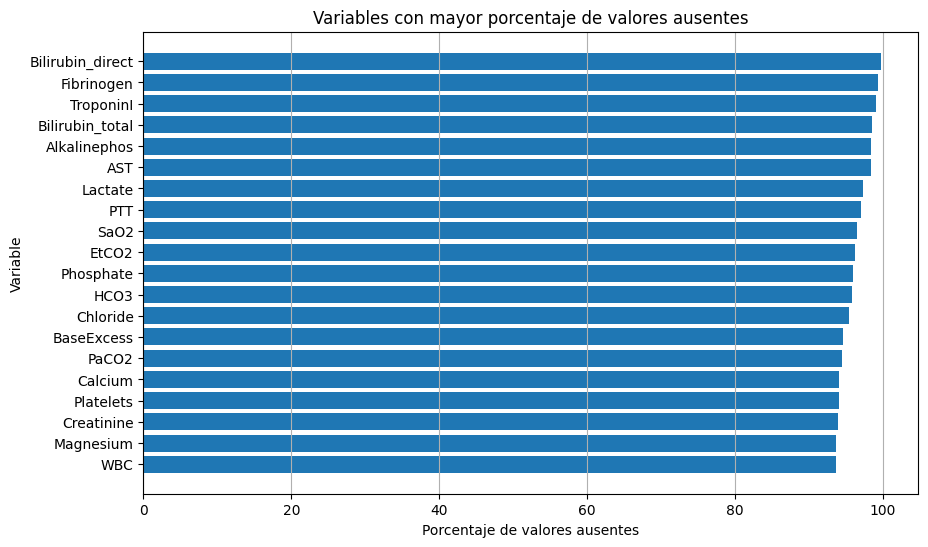

In [41]:
import matplotlib.pyplot as plt

top_missing = missing_global.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_missing["Variable"], top_missing["Porcentaje ausentes"])
plt.xlabel("Porcentaje de valores ausentes")
plt.ylabel("Variable")
plt.title("Variables con mayor porcentaje de valores ausentes")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.show()

In [42]:
missing_por_grupo = pd.DataFrame({
    "Grupo": ["Signos vitales", "Laboratorio", "Demográficas"],
    "Porcentaje medio de ausentes": [
        df[signos_vitales].isna().mean().mean() * 100,
        df[laboratorio].isna().mean().mean() * 100,
        df[demograficas].isna().mean().mean() * 100
    ]
})

missing_por_grupo.round(2)

,Grupo,Porcentaje medio de ausentes
0,Signos vitales,32.39
1,Laboratorio,94.82
2,Demográficas,13.14


Observamos que la mayoría de valores ausentes se concentran en las variables de laboratorio. Esto tiene sentido pues son variables cuyos valores es más difícil de obtener y se suele obtener solo una vez por paciente.

In [43]:
missing_hospital = (
    df.groupby("Hospital")[variables_modelo]
    .apply(lambda x: x.isna().mean() * 100)
    .T
)

missing_hospital["Diferencia absoluta"] = (
    missing_hospital["A"] - missing_hospital["B"]
).abs()

missing_hospital.sort_values("Diferencia absoluta", ascending=False).head(15).round(2)

Hospital,A,B,Diferencia absoluta
DBP,48.13,13.94,34.18
Unit2,48.87,29.63,19.24
Unit1,48.87,29.63,19.24
FiO2,85.81,97.74,11.93
Resp,9.78,21.14,11.36
BaseExcess,89.57,99.77,10.19
Glucose,87.77,77.84,9.93
pH,88.53,97.77,9.24
HCO3,91.95,99.81,7.87
Chloride,91.68,99.38,7.71


La diferencia global no afecta por igual a todas las variables, pero existen variables concretas con diferencias relevantes entre hospitales, especialmente DBP, Unit1, Unit2 y algunas variables de laboratorio.

In [44]:
# Creamos una etiqueta a nivel paciente: 1 si el paciente tuvo sepsis en algún momento
df_paciente_sepsis = df.groupby("PatientID")["SepsisLabel"].max().reset_index()
df_paciente_sepsis = df_paciente_sepsis.rename(columns={"SepsisLabel": "TieneSepsis"})

# Añadimos esa etiqueta al DataFrame completo
df_missing_sepsis = df.merge(df_paciente_sepsis, on="PatientID", how="left")

missing_sepsis = (
    df_missing_sepsis.groupby("TieneSepsis")[variables_modelo]
    .apply(lambda x: x.isna().mean() * 100)
    .T
)

missing_sepsis = missing_sepsis.rename(columns={
    0: "Pacientes sin sepsis",
    1: "Pacientes con sepsis"
})

missing_sepsis["Diferencia absoluta"] = (
    missing_sepsis["Pacientes sin sepsis"] - missing_sepsis["Pacientes con sepsis"]
).abs()

missing_sepsis.sort_values("Diferencia absoluta", ascending=False).head(15).round(2)

TieneSepsis,Pacientes sin sepsis,Pacientes con sepsis,Diferencia absoluta
Unit1,38.19,49.27,11.08
Unit2,38.19,49.27,11.08
FiO2,92.72,83.26,9.45
EtCO2,97.14,89.49,7.64
DBP,32.11,25.26,6.85
pH,93.60,88.86,4.73
O2Sat,13.55,9.16,4.39
MAP,12.93,8.61,4.32
PaCO2,94.89,90.82,4.07
BaseExcess,95.01,91.12,3.89


Las diferencias entre pacientes con y sin sepsis son menores que las observadas entre hospitales, aunque algunas variables administrativas y clínicas presentan diferencias puntuales.

In [45]:
# Porcentaje de ausentes por fila, considerando solo variables del modelo
df_temporal_missing = df[["PatientID", "Hospital", "TimeStep", "ICULOS"]].copy()
df_temporal_missing["PorcentajeAusentesFila"] = df[variables_modelo].isna().mean(axis=1) * 100

# Agrupamos TimeStep en intervalos para verlo más claro
bins = [0, 12, 24, 48, 72, 120, float("inf")]
labels = ["1-12", "13-24", "25-48", "49-72", "73-120", ">120"]

df_temporal_missing["IntervaloTimeStep"] = pd.cut(
    df_temporal_missing["TimeStep"],
    bins=bins,
    labels=labels
)

missing_temporal = df_temporal_missing.groupby("IntervaloTimeStep")["PorcentajeAusentesFila"].agg(
    media="mean",
    mediana="median",
    registros="count"
).reset_index()

missing_temporal.round(2)

/tmp/ipykernel_9850/2805663001.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  missing_temporal = df_temporal_missing.groupby("IntervaloTimeStep")["PorcentajeAusentesFila"].agg(


,IntervaloTimeStep,media,mediana,registros
0,1-12,69.21,70.0,481336
1,13-24,70.43,70.0,426189
2,25-48,70.67,70.0,509616
3,49-72,70.22,70.0,68688
4,73-120,69.11,70.0,34750
5,>120,69.89,70.0,31631


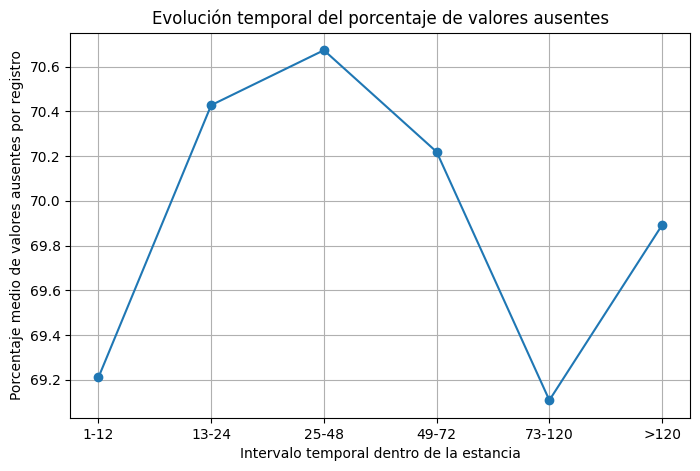

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(
    missing_temporal["IntervaloTimeStep"].astype(str),
    missing_temporal["media"],
    marker="o"
)
plt.xlabel("Intervalo temporal dentro de la estancia")
plt.ylabel("Porcentaje medio de valores ausentes por registro")
plt.title("Evolución temporal del porcentaje de valores ausentes")
plt.grid(True)
plt.show()

El porcentaje medio de valores ausentes parece aumentar en los registros temporales comprendidos entre los instantes 25 y 48. No obstante, esta tendencia debe interpretarse con cautela, ya que el número de registros disponibles varía entre intervalos temporales.

In [47]:
def recomendar_tratamiento(porcentaje):
    if porcentaje >= 90:
        return "Candidata a descartar por exceso de ausentes"
    elif porcentaje >= 60:
        return "Estudiar si aporta información antes de imputar o descartar"
    elif porcentaje >= 30:
        return "Imputación con posible indicador de ausencia"
    elif porcentaje > 0:
        return "Imputación estándar"
    else:
        return "Sin valores ausentes"

decision_missing = missing_global.copy()
decision_missing["Recomendación preliminar"] = decision_missing["Porcentaje ausentes"].apply(
    recomendar_tratamiento
)

decision_missing.round(2)

,Variable,Porcentaje ausentes,Recomendación preliminar
20,Bilirubin_direct,99.81,Candidata a descartar por exceso de ausentes
32,Fibrinogen,99.34,Candidata a descartar por exceso de ausentes
27,TroponinI,99.05,Candidata a descartar por exceso de ausentes
26,Bilirubin_total,98.51,Candidata a descartar por exceso de ausentes
16,Alkalinephos,98.39,Candidata a descartar por exceso de ausentes
14,AST,98.38,Candidata a descartar por exceso de ausentes
22,Lactate,97.33,Candidata a descartar por exceso de ausentes
30,PTT,97.06,Candidata a descartar por exceso de ausentes
13,SaO2,96.55,Candidata a descartar por exceso de ausentes
7,EtCO2,96.29,Candidata a descartar por exceso de ausentes


El análisis de valores ausentes muestra que la ausencia de datos no se distribuye de forma uniforme entre variables. Las variables de laboratorio presentan, en general, porcentajes de ausencia más elevados que los signos vitales y las variables demográficas. Además, se observan diferencias en la disponibilidad de algunas mediciones según el hospital de procedencia y según la presencia de sepsis a nivel de paciente. Estos resultados deberán tenerse en cuenta en la etapa de preprocesamiento, especialmente para decidir qué variables descartar, qué variables imputar y si resulta conveniente incorporar indicadores de ausencia para determinadas mediciones.

# 6. Estadísticos descriptivos

In [48]:
estadisticos_generales = df[variables_modelo].describe().T

# Añadimos la mediana explícitamente
estadisticos_generales["median"] = df[variables_modelo].median()

# Reordenamos columnas
estadisticos_generales = estadisticos_generales[
    ["count", "mean", "std", "median", "min", "25%", "50%", "75%", "max"]
]

estadisticos_generales.round(2)

,count,mean,std,median,min,25%,50%,75%,max
HR,1398811.0,84.58,17.33,83.50,20.00,72.00,83.50,95.50,280.00
O2Sat,1349474.0,97.19,2.94,98.00,20.00,96.00,98.00,99.50,100.00
Temp,525226.0,36.98,0.77,37.00,20.90,36.50,37.00,37.50,50.00
SBP,1325945.0,123.75,23.23,121.00,20.00,107.00,121.00,138.00,300.00
MAP,1358940.0,82.40,16.34,80.00,20.00,71.00,80.00,92.00,300.00
DBP,1065656.0,63.83,13.96,62.00,20.00,54.00,62.00,72.00,300.00
Resp,1313875.0,18.73,5.10,18.00,1.00,15.00,18.00,21.50,100.00
EtCO2,57636.0,32.96,7.95,33.00,10.00,28.00,33.00,38.00,100.00
BaseExcess,84145.0,-0.69,4.29,0.00,-32.00,-3.00,0.00,1.00,100.00
HCO3,65028.0,24.08,4.38,24.00,0.00,22.00,24.00,26.80,55.00


Los estadísticos descriptivos muestran que las variables presentan escalas y rangos muy diferentes entre sí. Esto es esperable, ya que el conjunto de datos incluye signos vitales, variables analíticas y datos demográficos medidos en unidades distintas. Esta diferencia de escala deberá tenerse en cuenta en el preprocesamiento, especialmente para aquellos modelos sensibles a la magnitud de las variables.

También se observan valores mínimos y máximos alejados del rango central de algunas variables. Estos casos serán analizados con mayor detalle en el apartado dedicado a valores extremos y posibles anomalías.

In [49]:
def resumen_descriptivo(columnas):
    return df[columnas].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

estadisticos_signos_vitales = resumen_descriptivo(signos_vitales)
estadisticos_laboratorio = resumen_descriptivo(laboratorio)
estadisticos_demograficas = resumen_descriptivo(demograficas)

print("Signos vitales")
display(estadisticos_signos_vitales)

print("Variables de laboratorio")
display(estadisticos_laboratorio)

print("Variables demográficas")
display(estadisticos_demograficas)

Signos vitales


,count,mean,std,min,25%,50%,75%,max
HR,1398811.0,84.58,17.33,20.0,72.0,83.5,95.5,280.0
O2Sat,1349474.0,97.19,2.94,20.0,96.0,98.0,99.5,100.0
Temp,525226.0,36.98,0.77,20.9,36.5,37.0,37.5,50.0
SBP,1325945.0,123.75,23.23,20.0,107.0,121.0,138.0,300.0
MAP,1358940.0,82.40,16.34,20.0,71.0,80.0,92.0,300.0
DBP,1065656.0,63.83,13.96,20.0,54.0,62.0,72.0,300.0
Resp,1313875.0,18.73,5.10,1.0,15.0,18.0,21.5,100.0
EtCO2,57636.0,32.96,7.95,10.0,28.0,33.0,38.0,100.0


Variables de laboratorio


,count,mean,std,min,25%,50%,75%,max
BaseExcess,84145.0,-0.69,4.29,-32.00,-3.00,0.00,1.00,100.00
HCO3,65028.0,24.08,4.38,0.00,22.00,24.00,26.80,55.00
FiO2,129365.0,0.55,11.12,-50.00,0.40,0.50,0.60,4000.00
pH,107573.0,7.38,0.07,6.62,7.34,7.38,7.43,7.93
PaCO2,86301.0,41.02,9.27,10.00,35.00,40.00,45.00,100.00
SaO2,53561.0,92.65,10.89,23.00,94.00,97.00,98.00,100.00
AST,25183.0,260.22,855.75,3.00,22.00,41.00,111.00,9961.00
BUN,106568.0,23.92,19.99,1.00,12.00,17.00,28.00,268.00
Alkalinephos,24941.0,102.48,120.12,7.00,54.00,74.00,108.00,3833.00
Calcium,91331.0,7.56,2.43,1.00,7.70,8.30,8.70,27.90


Variables demográficas


,count,mean,std,min,25%,50%,75%,max
Age,1552210.0,62.01,16.39,14.00,51.68,64.00,74.00,100.00
Gender,1552210.0,0.56,0.50,0.00,0.00,1.00,1.00,1.00
Unit1,940250.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Unit2,940250.0,0.50,0.50,0.00,0.00,1.00,1.00,1.00
HospAdmTime,1552202.0,-56.13,162.26,-5366.86,-47.05,-6.03,-0.04,23.99
ICULOS,1552210.0,26.99,29.01,1.00,11.00,21.00,34.00,336.00


Al separar las variables por grupos, se observa que los signos vitales presentan valores más completos y rangos generalmente más acotados, mientras que varias variables de laboratorio muestran una mayor dispersión y menor número de observaciones disponibles. Esto resulta coherente con la naturaleza del entorno clínico, ya que las constantes vitales suelen registrarse con mayor frecuencia que las pruebas analíticas.

In [50]:
df_stats_sepsis = df.merge(df_paciente_sepsis, on="PatientID", how="left")

variables_clave = ["HR", "O2Sat", "Temp", "MAP", "Resp", "Lactate", "Creatinine", "WBC", "Platelets", "Age"]

medianas_sepsis = df_stats_sepsis.groupby("TieneSepsis")[variables_clave].median().T
medianas_sepsis.columns = ["Pacientes sin sepsis", "Pacientes con sepsis"]
medianas_sepsis["Diferencia absoluta"] = (
    medianas_sepsis["Pacientes con sepsis"] - medianas_sepsis["Pacientes sin sepsis"]
).abs()

medianas_sepsis.sort_values("Diferencia absoluta", ascending=False).round(2)



,Pacientes sin sepsis,Pacientes con sepsis,Diferencia absoluta
Platelets,182.00,168.00,14.00
HR,83.00,87.00,4.00
WBC,10.20,11.30,1.10
Resp,18.00,19.00,1.00
Age,64.00,64.94,0.94
Creatinine,0.91,1.10,0.19
Temp,37.00,37.11,0.11
Lactate,1.80,1.85,0.05
O2Sat,98.00,98.00,0.00
MAP,80.00,80.00,0.00


La comparación entre pacientes con y sin sepsis muestra diferencias en algunas variables clínicas principales. Estas diferencias no deben interpretarse como relaciones causales, pero sí indican que determinadas variables podrían aportar información útil para distinguir ambos grupos. En particular, se observan diferencias en variables como `Platelets` y `HR`, aunque estas diferencias no son suficientes por sí solas para separar claramente ambos grupos.




In [51]:
medianas_hospital = df.groupby("Hospital")[variables_clave].median().T

medianas_hospital["Diferencia absoluta"] = (
    medianas_hospital["A"] - medianas_hospital["B"]
).abs()

medianas_hospital.sort_values("Diferencia absoluta", ascending=False).round(2)

Hospital,A,B,Diferencia absoluta
MAP,77.00,84.00,7.00
Age,65.25,63.00,2.25
WBC,10.80,9.60,1.20
HR,84.00,83.00,1.00
Platelets,181.00,180.00,1.00
Lactate,1.80,1.97,0.17
Temp,37.06,36.90,0.16
Creatinine,0.90,0.99,0.09
O2Sat,98.00,98.00,0.00
Resp,18.00,18.00,0.00


A continuación, buscamos variables con pocos valores únicos o con un valor dominante en la mayoría de registros. Estas variables podrían aportar poca información al modelo y deberán revisarse durante el preprocesamiento para decidir si se mantienen, se transforman o se eliminan.

In [52]:

variabilidad = pd.DataFrame({
    "Variable": variables_modelo,
    "Valores únicos": df[variables_modelo].nunique(dropna=True).values,
    "Desviación típica": df[variables_modelo].std().values,
    "Porcentaje valor más frecuente": [
        df[col].value_counts(normalize=True, dropna=True).iloc[0] * 100
        if df[col].dropna().shape[0] > 0 else None
        for col in variables_modelo
    ]
})

variabilidad = variabilidad.sort_values("Porcentaje valor más frecuente", ascending=False)

variabilidad.round(2)

,Variable,Valores únicos,Desviación típica,Porcentaje valor más frecuente
35,Gender,2,0.50,55.93
36,Unit1,2,0.50,50.34
37,Unit2,2,0.50,50.34
10,FiO2,104,11.12,34.51
1,O2Sat,145,2.94,24.19
8,BaseExcess,407,4.29,23.02
13,SaO2,432,10.89,20.70
20,Bilirubin_direct,280,3.69,18.09
23,Magnesium,110,0.40,13.33
27,TroponinI,2423,24.81,12.10


Vemos que las primeras variables corresponden a variables binarias y administrativas, por lo que su baja variabilidad puede deberse a su propia naturaleza y no necesariamente a un problema de calidad del dato.

In [53]:
variables_casi_constantes = variabilidad[
    (variabilidad["Valores únicos"] <= 2) |
    (variabilidad["Porcentaje valor más frecuente"] >= 95)
]

variables_casi_constantes.round(2)

,Variable,Valores únicos,Desviación típica,Porcentaje valor más frecuente
35,Gender,2,0.5,55.93
36,Unit1,2,0.5,50.34
37,Unit2,2,0.5,50.34


Las variables detectadas con pocos valores únicos corresponden principalmente a variables binarias o administrativas, por lo que su baja variedad de valores se debe a su propia naturaleza. No se observan variables numéricas continuas completamente constantes.

Los estadísticos descriptivos permiten obtener una primera visión de la escala, dispersión y rango de las variables. Estos resultados serán útiles para definir posteriormente estrategias de imputación, escalado y detección de valores extremos.

# 7. Distribuciones de variables

In [54]:
variables_dist = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "Resp",
    "Lactate", "Creatinine", "WBC", "Platelets", "Age"
]

# Nos aseguramos de que existan en el DataFrame
variables_dist = [var for var in variables_dist if var in df.columns]

# Usamos una muestra para que los gráficos sean más rápidos
df_plot = df.sample(n=min(200000, len(df)), random_state=42)

variables_dist

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'Resp',
 'Lactate',
 'Creatinine',
 'WBC',
 'Platelets',
 'Age']

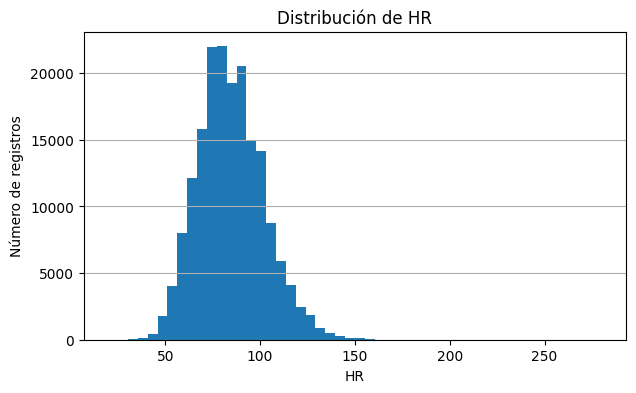

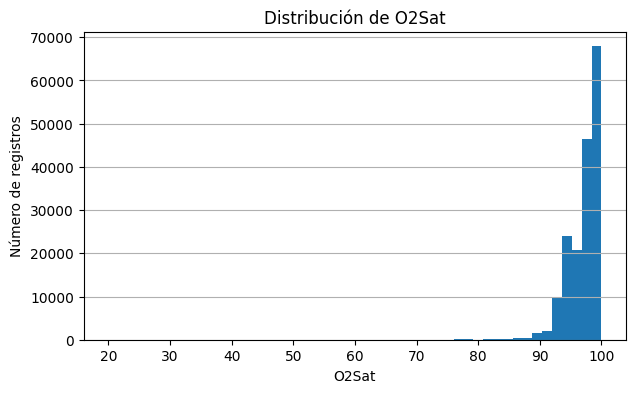

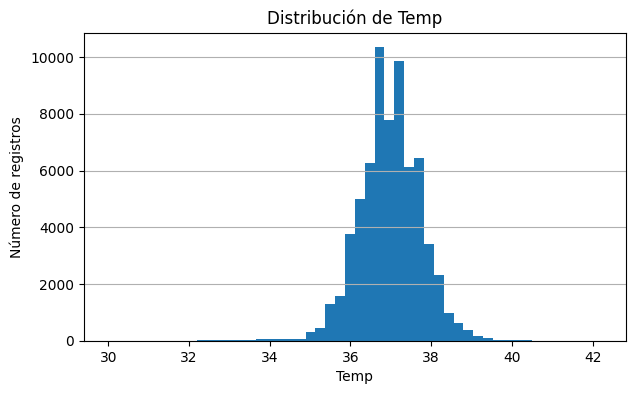

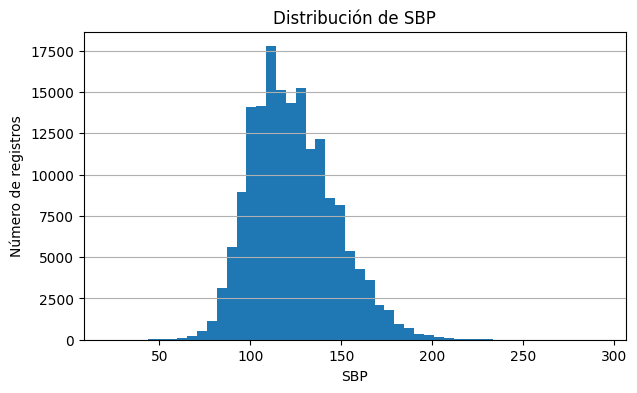

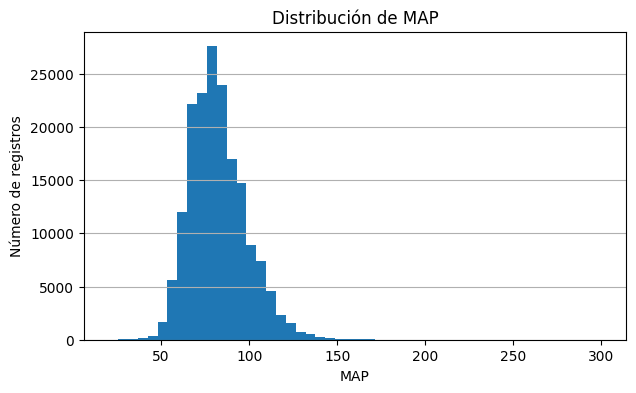

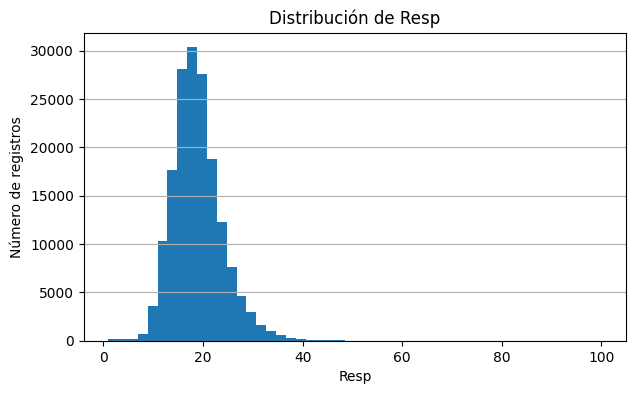

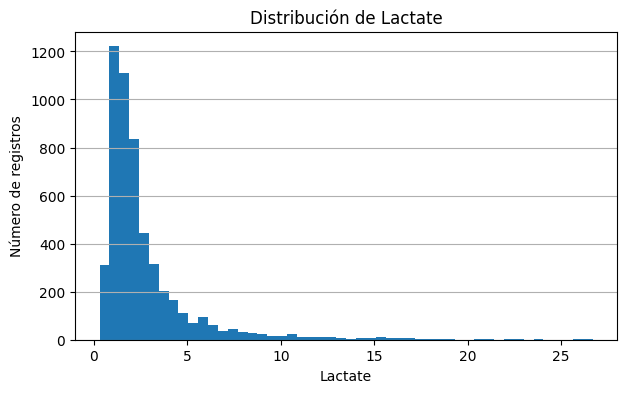

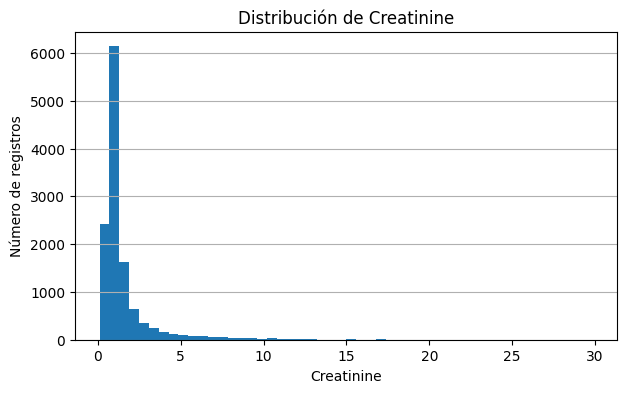

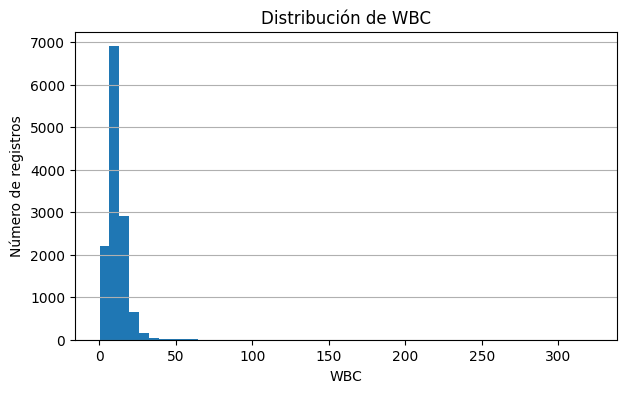

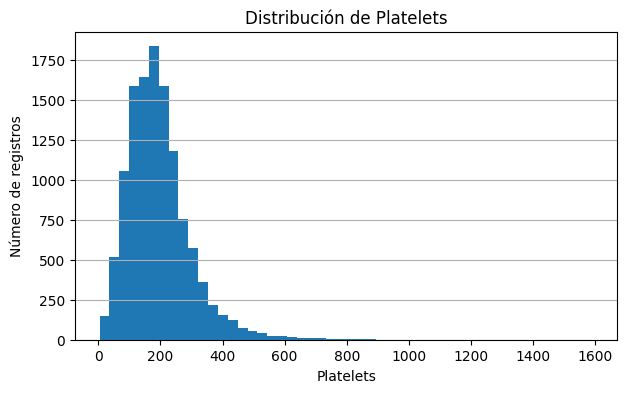

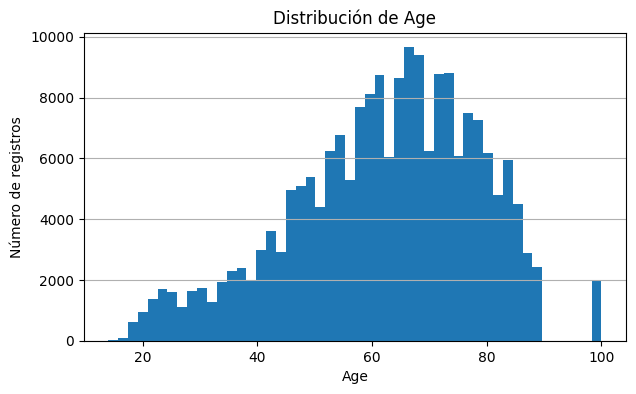

In [55]:
for var in variables_dist:
    plt.figure(figsize=(7, 4))
    plt.hist(df_plot[var].dropna(), bins=50)
    plt.xlabel(var)
    plt.ylabel("Número de registros")
    plt.title(f"Distribución de {var}")
    plt.grid(axis="y")
    plt.show()

 En algunas variables, la presencia de valores extremos dificulta la visualización de la distribución central. Por ello, estas variables se revisarán con mayor detalle en el análisis de outliers.

In [56]:
asimetria = pd.DataFrame({
    "Variable": variables_dist,
    "Asimetría": df[variables_dist].skew(numeric_only=True).values
})

asimetria["Asimetría absoluta"] = asimetria["Asimetría"].abs()

asimetria = asimetria.sort_values("Asimetría absoluta", ascending=False)

asimetria.round(2)

,Variable,Asimetría,Asimetría absoluta
8,WBC,14.93,14.93
7,Creatinine,4.63,4.63
1,O2Sat,-4.15,4.15
6,Lactate,3.41,3.41
9,Platelets,1.84,1.84
4,MAP,1.05,1.05
5,Resp,0.97,0.97
3,SBP,0.56,0.56
10,Age,-0.46,0.46
0,HR,0.43,0.43


La asimetría es una medida estadística que mide cómo de "deformada" está la distribución de una variale en comparación con una distribución normal. El cálculo de la asimetría confirma que algunas variables presentan distribuciones alejadas de la normalidad, especialmente determinadas variables de laboratorio. Esto sugiere que la media puede no ser siempre una medida representativa del comportamiento central de estas variables, por lo que en el análisis descriptivo resulta conveniente considerar también la mediana y los cuartiles.

In [57]:
medianas_sepsislabel = df.groupby("SepsisLabel")[variables_dist].median().T

medianas_sepsislabel.columns = ["SepsisLabel = 0", "SepsisLabel = 1"]

medianas_sepsislabel["Diferencia absoluta"] = (
    medianas_sepsislabel["SepsisLabel = 1"] - medianas_sepsislabel["SepsisLabel = 0"]
).abs()

medianas_sepsislabel.sort_values("Diferencia absoluta", ascending=False).round(2)

,SepsisLabel = 0,SepsisLabel = 1,Diferencia absoluta
Platelets,181.00,163.0,18.00
HR,83.00,90.0,7.00
SBP,121.00,118.0,3.00
Resp,18.00,20.0,2.00
MAP,80.00,78.0,2.00
WBC,10.30,11.8,1.50
Temp,37.00,37.3,0.30
Creatinine,0.93,1.2,0.27
Lactate,1.80,1.7,0.10
O2Sat,98.00,98.0,0.00


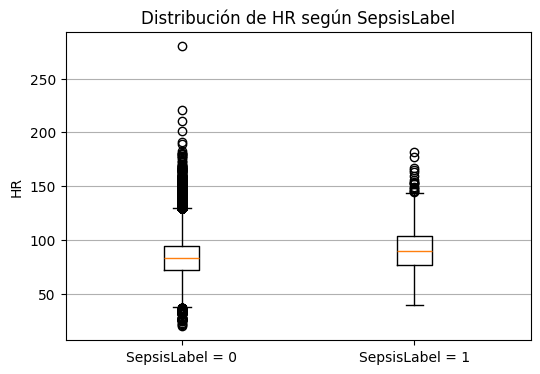

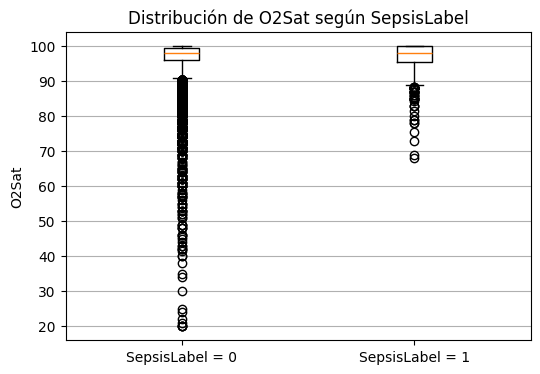

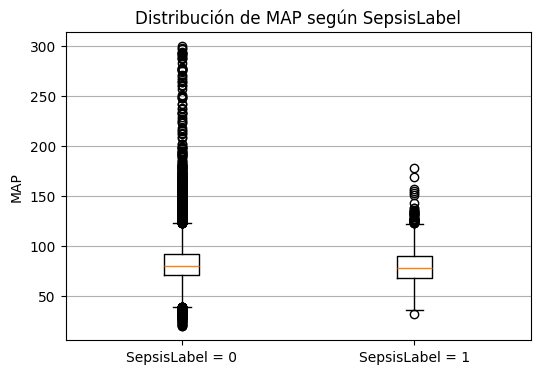

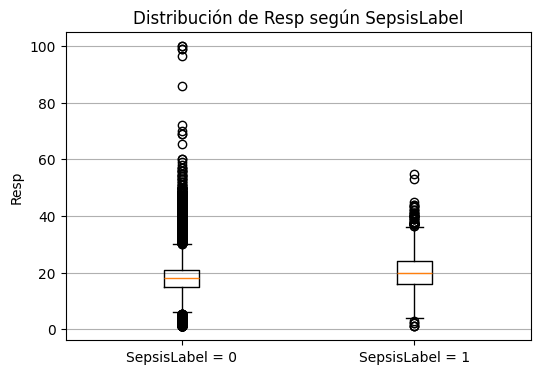

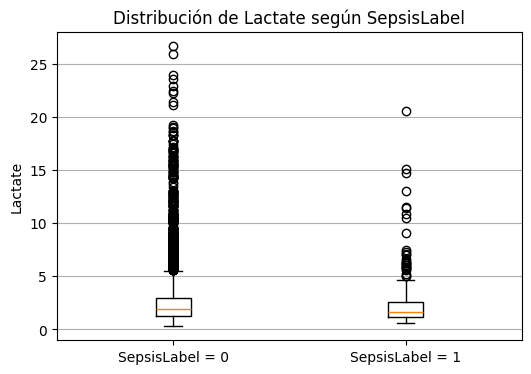

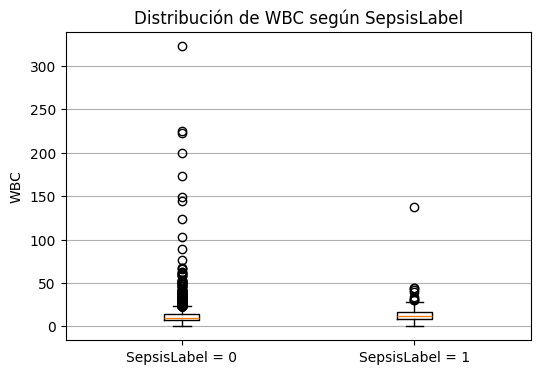

In [58]:
variables_comparar = ["HR", "O2Sat", "MAP", "Resp", "Lactate", "WBC"]

variables_comparar = [var for var in variables_comparar if var in df.columns]

for var in variables_comparar:
    data_0 = df_plot[df_plot["SepsisLabel"] == 0][var].dropna()
    data_1 = df_plot[df_plot["SepsisLabel"] == 1][var].dropna()

    plt.figure(figsize=(6, 4))
    plt.boxplot([data_0, data_1], tick_labels=["SepsisLabel = 0", "SepsisLabel = 1"])
    plt.ylabel(var)
    plt.title(f"Distribución de {var} según SepsisLabel")
    plt.grid(axis="y")
    plt.show()

Los boxplots muestran que existen algunas diferencias en la distribución de determinadas variables según el valor de `SepsisLabel`. En los registros positivos se observa una frecuencia cardíaca (`HR`) y una frecuencia respiratoria (`Resp`) ligeramente superiores, así como ciertas diferencias en variables como `MAP` y `WBC`. Sin embargo, el solapamiento entre ambas clases es elevado, por lo que ninguna variable individual permite separar claramente los registros con y sin sepsis.

También se observa la presencia de numerosos valores extremos, especialmente en los registros con `SepsisLabel = 0`. Esta mayor presencia de outliers en la clase negativa debe interpretarse con cautela, ya que dicha clase contiene un número de registros mucho mayor. En cualquier caso, al tratarse de variables clínicas, estos valores no deben eliminarse automáticamente, sino que deberán revisarse en la etapa de análisis de outliers y preprocesamiento.

En conjunto, estos resultados sugieren que la predicción de sepsis probablemente dependerá de la combinación de múltiples variables clínicas y no de una única medición aislada.

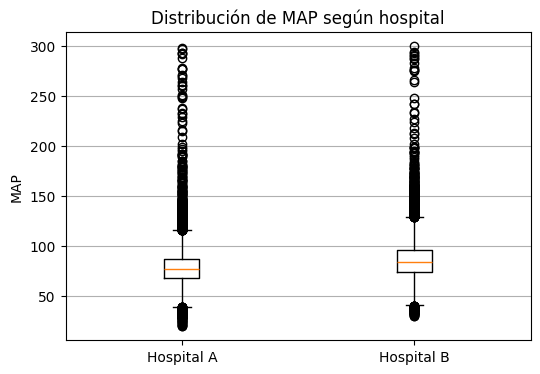

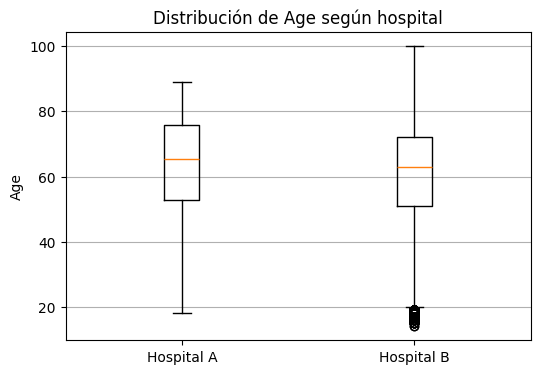

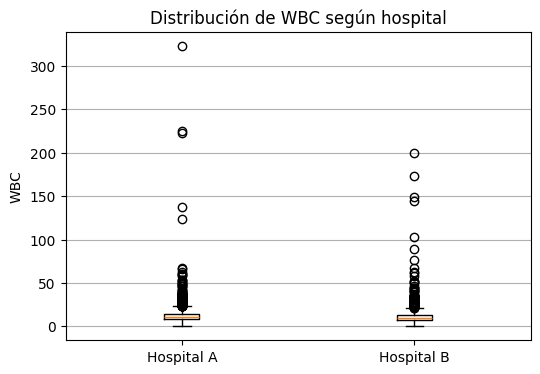

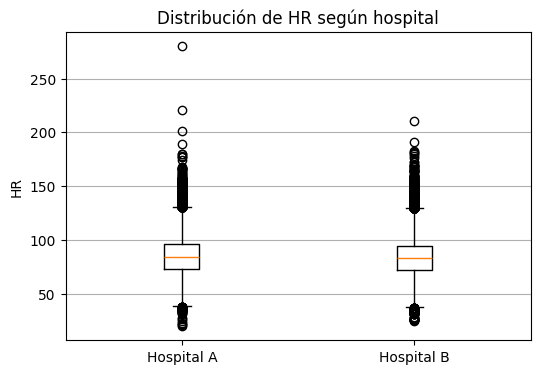

In [59]:
top_vars_hospital = (
    medianas_hospital["Diferencia absoluta"]
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

for var in top_vars_hospital:
    data_A = df_plot[df_plot["Hospital"] == "A"][var].dropna()
    data_B = df_plot[df_plot["Hospital"] == "B"][var].dropna()

    plt.figure(figsize=(6, 4))
    plt.boxplot([data_A, data_B], tick_labels=["Hospital A", "Hospital B"])
    plt.ylabel(var)
    plt.title(f"Distribución de {var} según hospital")
    plt.grid(axis="y")
    plt.show()

La comparación de las distribuciones según hospital muestra que ambos conjuntos presentan comportamientos similares en las variables clínicas principales, aunque existen algunas diferencias puntuales. En `MAP`, el hospital B presenta una mediana ligeramente superior, mientras que en `Age` el hospital A muestra una mediana algo mayor. Para variables como `WBC` y `HR`, las distribuciones centrales son bastante parecidas entre hospitales, aunque se observan valores extremos en ambos conjuntos.

En general, los boxplots no muestran una separación clara entre hospitales en las variables analizadas, pero sí pequeñas diferencias en algunas distribuciones. Esto refuerza la decisión de utilizar ambos conjuntos de forma conjunta, manteniendo la variable `Hospital` como información auxiliar para controlar posibles diferencias asociadas a la procedencia de los datos.

# 8. Outliers y valores anómalos

In [60]:
variables_outliers = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp",
    "Lactate", "Creatinine", "WBC", "Platelets", "Age"
]


resumen_rangos = df[variables_outliers].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

resumen_rangos = resumen_rangos[
    ["count", "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]
]

resumen_rangos.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
HR,1398811.0,84.58,17.33,20.0,50.00,59.0,72.00,83.50,95.50,115.00,130.00,280.0
O2Sat,1349474.0,97.19,2.94,20.0,89.00,92.5,96.00,98.00,99.50,100.00,100.00,100.0
Temp,525226.0,36.98,0.77,20.9,35.10,35.8,36.50,37.00,37.50,38.20,38.80,50.0
SBP,1325945.0,123.75,23.23,20.0,80.00,91.0,107.00,121.00,138.00,165.00,186.00,300.0
MAP,1358940.0,82.40,16.34,20.0,52.00,60.0,71.00,80.00,92.00,111.00,128.00,300.0
DBP,1065656.0,63.83,13.96,20.0,38.00,44.0,54.00,62.00,72.00,89.00,103.00,300.0
Resp,1313875.0,18.73,5.10,1.0,9.00,12.0,15.00,18.00,21.50,28.00,34.00,100.0
Lactate,41446.0,2.65,2.53,0.2,0.60,0.8,1.26,1.80,3.00,7.35,14.22,31.0
Creatinine,94616.0,1.51,1.81,0.1,0.37,0.5,0.70,0.94,1.43,4.90,9.70,46.6
WBC,99447.0,11.45,7.73,0.1,2.50,4.5,7.60,10.30,13.80,21.30,31.20,440.0


La revisión de mínimos, máximos y percentiles permite identificar variables con valores alejados del rango central de la distribución. En varias variables se observan diferencias importantes entre los percentiles 95/99 y los valores máximos, lo que indica la presencia de valores extremos. Estos valores no se eliminan en esta fase, sino que se revisan como parte del análisis de calidad de los datos.

Para detectar posibles outliers utilizamos el criterio del Rango Intercuatílico (IQR, por sus siglas en inglés), uno de los métodos más robustos y utilizados para detectar valores atípicos.

In [61]:
outliers_iqr = []

for var in variables_outliers:
    serie = df[var].dropna()

    # Encontramos los cuartiles Q1 y Q3
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    #Calculamos el rango intercuartílico (IQR)
    iqr = q3 - q1

    # Establecemos los límites dentro de los cuales deberían encontrarse los
    # valores "típicos"
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    n_outliers = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    porcentaje_outliers = n_outliers / len(serie) * 100

    outliers_iqr.append({
        "Variable": var,
        "Q1": q1,
        "Q3": q3,
        "Límite inferior IQR": limite_inferior,
        "Límite superior IQR": limite_superior,
        "Nº outliers": n_outliers,
        "% outliers": porcentaje_outliers
    })

outliers_iqr = pd.DataFrame(outliers_iqr)
outliers_iqr.sort_values("% outliers", ascending=False).round(2)

,Variable,Q1,Q3,Límite inferior IQR,Límite superior IQR,Nº outliers,% outliers
8,Creatinine,0.70,1.43,-0.40,2.52,11139,11.77
7,Lactate,1.26,3.00,-1.35,5.61,3529,8.51
9,WBC,7.60,13.80,-1.70,23.10,3475,3.49
10,Platelets,126.00,244.00,-51.00,421.00,2925,3.17
6,Resp,15.00,21.50,5.25,31.25,27855,2.12
1,O2Sat,96.00,99.50,90.75,104.75,24782,1.84
4,MAP,71.00,92.00,39.50,123.50,21894,1.61
5,DBP,54.00,72.00,27.00,99.00,16296,1.53
2,Temp,36.50,37.50,35.00,39.00,6569,1.25
3,SBP,107.00,138.00,60.50,184.50,15842,1.19


Debe tenerse en cuenta que en datos clínicos este criterio debe interpretarse con cautela, ya que un valor estadísticamente atípico no implica necesariamente que sea erróneo. Algunas observaciones extremas pueden corresponder a situaciones reales de gravedad clínica, por lo que no se eliminarán automáticamente.

 Por otra parte, los boxplots analizados en la sección anterior confirman la presencia de valores extremos en varias variables clínicas, especialmente en algunas variables de laboratorio y constantes fisiológicas. La concentración de muchos valores alrededor del rango central y la presencia de puntos alejados indican distribuciones asimétricas o con colas largas. Estos resultados refuerzan la necesidad de estudiar estrategias de tratamiento robustas durante el preprocesamiento.


A continuación, se revisan rangos orientativos para algunas variables.

In [62]:
rangos_orientativos = {
    "HR": (20, 250),
    "O2Sat": (50, 100),
    "Temp": (30, 45),
    "SBP": (40, 300),
    "MAP": (20, 250),
    "DBP": (20, 200),
    "Resp": (1, 80),
    "Lactate": (0, 30),
    "Creatinine": (0, 20),
    "WBC": (0, 150),
    "Platelets": (0, 1500),
    "Age": (0, 120)
}

valores_fuera_rango = []

for var, (lim_inf, lim_sup) in rangos_orientativos.items():
    if var in df.columns:
        serie = df[var].dropna()

        n_bajos = (serie < lim_inf).sum()
        n_altos = (serie > lim_sup).sum()
        n_total = len(serie)

        valores_fuera_rango.append({
            "Variable": var,
            "Límite inferior orientativo": lim_inf,
            "Límite superior orientativo": lim_sup,
            "Valores por debajo": n_bajos,
            "Valores por encima": n_altos,
            "% fuera de rango": (n_bajos + n_altos) / n_total * 100
        })

valores_fuera_rango = pd.DataFrame(valores_fuera_rango)
valores_fuera_rango.sort_values("% fuera de rango", ascending=False).round(3)

,Variable,Límite inferior orientativo,Límite superior orientativo,Valores por debajo,Valores por encima,% fuera de rango
8,Creatinine,0,20,0,38,0.040
9,WBC,0,150,0,37,0.037
1,O2Sat,50,100,272,0,0.020
4,MAP,20,250,0,201,0.015
5,DBP,20,200,0,103,0.010
3,SBP,40,300,114,0,0.009
10,Platelets,0,1500,0,4,0.004
6,Resp,1,80,0,50,0.004
2,Temp,30,45,16,2,0.003
7,Lactate,0,30,0,1,0.002


La revisión mediante rangos orientativos permite detectar posibles valores fisiológicamente muy improbables. Estos rangos se utilizan únicamente como una comprobación preliminar de calidad y no como criterio automático de eliminación. En caso de encontrar valores fuera de rango, deberán revisarse durante el preprocesamiento para decidir si corresponden a errores, valores extremos reales o registros que conviene limitar mediante técnicas de recorte.

In [63]:
decision_outliers = outliers_iqr[["Variable", "% outliers"]].merge(
    valores_fuera_rango[["Variable", "% fuera de rango"]],
    on="Variable",
    how="left"
)

def recomendar_tratamiento_outliers(row):
    if row["% fuera de rango"] > 0:
        return "Revisar valores fuera de rango antes del modelado"
    elif row["% outliers"] >= 10:
        return "Mantener inicialmente; valorar escalado robusto o recorte"
    elif row["% outliers"] > 0:
        return "Mantener; revisar durante el preprocesamiento"
    else:
        return "Sin outliers relevantes detectados"

decision_outliers["Recomendación preliminar"] = decision_outliers.apply(
    recomendar_tratamiento_outliers,
    axis=1
)

decision_outliers.sort_values("% outliers", ascending=False).round(2)

,Variable,% outliers,% fuera de rango,Recomendación preliminar
8,Creatinine,11.77,0.04,Revisar valores fuera de rango antes del modelado
7,Lactate,8.51,0.00,Revisar valores fuera de rango antes del modelado
9,WBC,3.49,0.04,Revisar valores fuera de rango antes del modelado
10,Platelets,3.17,0.00,Revisar valores fuera de rango antes del modelado
6,Resp,2.12,0.00,Revisar valores fuera de rango antes del modelado
1,O2Sat,1.84,0.02,Revisar valores fuera de rango antes del modelado
4,MAP,1.61,0.01,Revisar valores fuera de rango antes del modelado
5,DBP,1.53,0.01,Revisar valores fuera de rango antes del modelado
2,Temp,1.25,0.00,Revisar valores fuera de rango antes del modelado
3,SBP,1.19,0.01,Revisar valores fuera de rango antes del modelado


A partir del análisis realizado, no se plantea eliminar automáticamente los valores extremos. La estrategia inicial será conservarlos y revisar su tratamiento durante el preprocesamiento, especialmente en aquellas variables con mayor porcentaje de outliers o con valores fuera de rangos orientativos. En función del modelo utilizado, se estudiará la posibilidad de aplicar **escalado robusto**, **recorte de valores extremos** o **imputación específica**.

# 9. Correlaciones

En este apartado busamos detectar redundancias y relaciones básicas con `SepsisLabel`.

In [65]:
# Variables que se incluirán en el análisis de correlación
variables_corr = signos_vitales + laboratorio + ["Age", "HospAdmTime", "ICULOS", "SepsisLabel"]


# Calculamos correlación de Spearman
corr_matrix = df[variables_corr].corr(method="spearman")

corr_matrix.round(2)

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,HospAdmTime,ICULOS,SepsisLabel
HR,1.00,-0.06,0.26,-0.04,0.07,0.13,0.21,0.03,-0.06,-0.08,...,-0.09,-0.09,0.03,0.16,0.05,-0.02,-0.15,-0.09,0.04,0.05
O2Sat,-0.06,1.00,-0.05,0.01,0.02,-0.01,-0.16,-0.02,-0.04,-0.11,...,-0.14,-0.13,-0.01,0.00,-0.11,-0.04,-0.05,0.01,-0.11,-0.00
Temp,0.26,-0.05,1.00,-0.01,-0.07,-0.13,0.12,0.18,0.14,0.07,...,-0.05,-0.04,-0.13,0.10,0.27,-0.03,-0.06,-0.05,0.13,0.04
SBP,-0.04,0.01,-0.01,1.00,0.78,0.53,0.05,0.08,0.14,0.06,...,0.09,0.07,-0.17,-0.03,0.08,0.03,0.03,0.04,0.06,-0.02
MAP,0.07,0.02,-0.07,0.78,1.00,0.86,0.05,0.07,0.11,0.03,...,0.18,0.15,-0.13,-0.05,0.08,0.06,-0.16,0.06,0.02,-0.02
DBP,0.13,-0.01,-0.13,0.53,0.86,1.00,0.07,0.07,0.08,0.03,...,0.23,0.21,-0.11,-0.07,0.07,0.11,-0.29,0.11,-0.00,-0.02
Resp,0.21,-0.16,0.12,0.05,0.05,0.07,1.00,-0.16,-0.02,-0.04,...,0.02,-0.00,0.03,0.04,0.09,0.06,0.05,-0.01,0.10,0.04
EtCO2,0.03,-0.02,0.18,0.08,0.07,0.07,-0.16,1.00,0.20,0.35,...,0.09,0.06,-0.19,-0.01,0.20,0.19,-0.20,0.01,0.06,-0.02
BaseExcess,-0.06,-0.04,0.14,0.14,0.11,0.08,-0.02,0.20,1.00,0.82,...,-0.06,-0.04,-0.21,-0.16,0.18,0.07,-0.06,0.02,0.17,0.02
HCO3,-0.08,-0.11,0.07,0.06,0.03,0.03,-0.04,0.35,0.82,1.00,...,0.04,0.03,-0.15,-0.12,0.13,0.10,-0.00,-0.03,0.13,-0.01


Se calcula la matriz de correlación de Spearman entre las variables numéricas principales del conjunto de datos. Se utiliza este coeficiente porque permite analizar relaciones monótonas entre variables sin asumir una distribución normal, algo relevante en este dataset debido a la presencia de asimetrías y valores extremos.

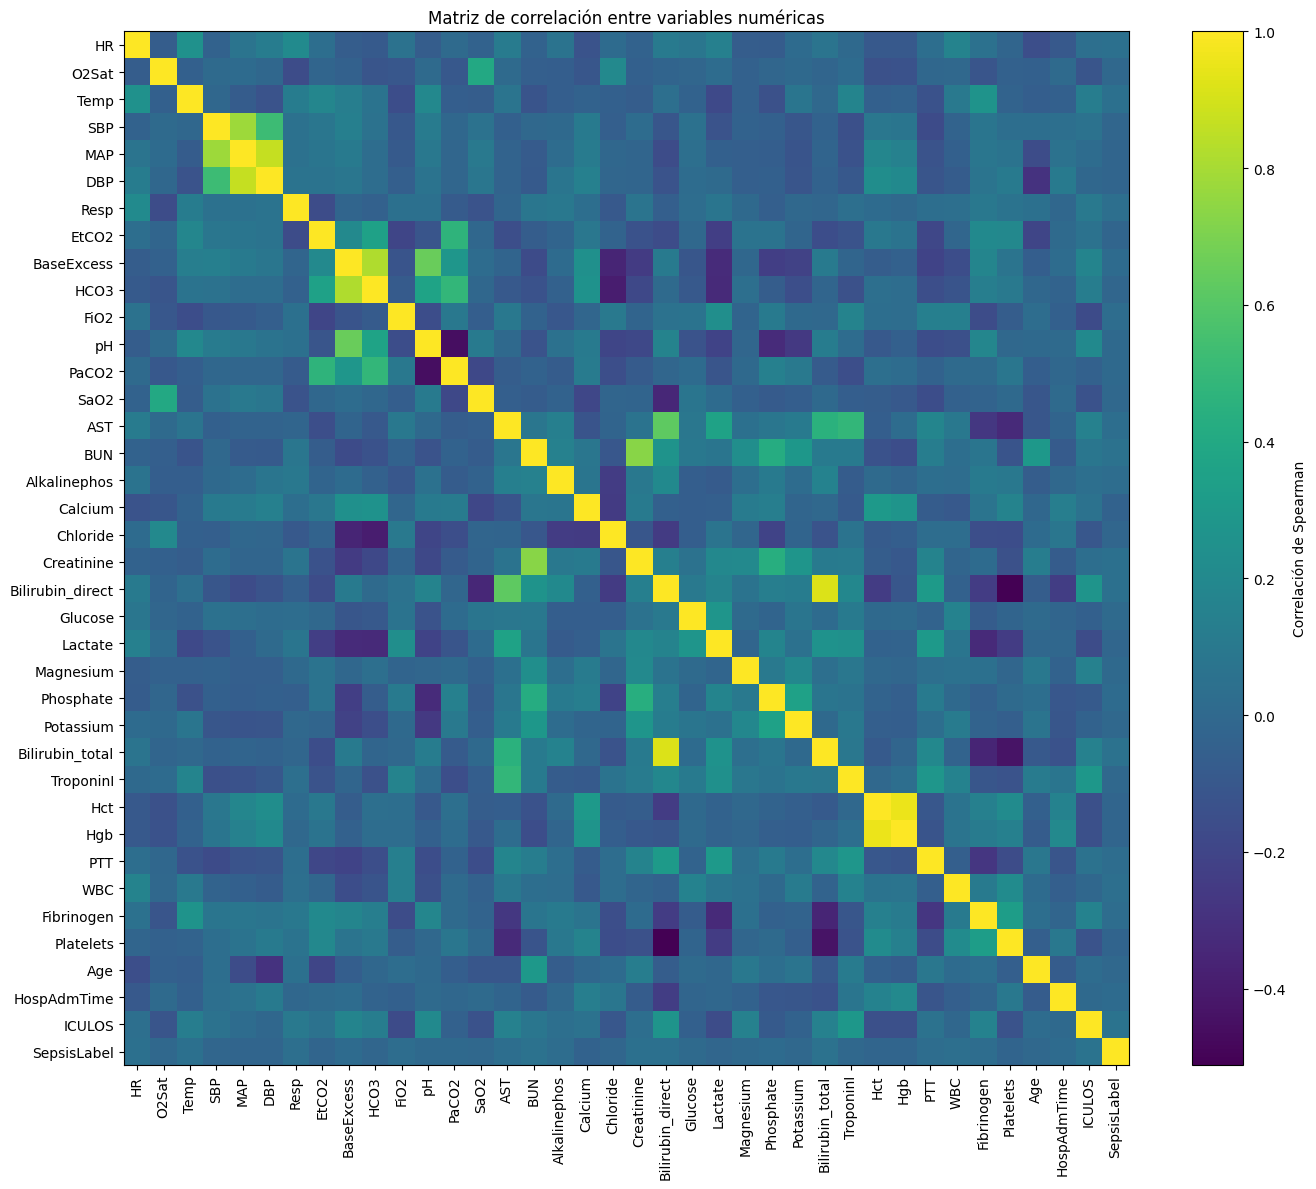

In [66]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 12))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlación de Spearman")

plt.xticks(ticks=np.arange(len(corr_matrix.columns)), labels=corr_matrix.columns, rotation=90)
plt.yticks(ticks=np.arange(len(corr_matrix.index)), labels=corr_matrix.index)

plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

In [67]:
# Convertimos la matriz en formato largo
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack().reset_index()

corr_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

# Calculamos valor absoluto
corr_pairs["Correlación absoluta"] = corr_pairs["Correlación"].abs()

# Filtramos correlaciones fuertes, excluyendo SepsisLabel
corr_fuertes = corr_pairs[
    (corr_pairs["Correlación absoluta"] >= 0.7) &
    (~corr_pairs["Variable 1"].eq("SepsisLabel")) &
    (~corr_pairs["Variable 2"].eq("SepsisLabel"))
].sort_values("Correlación absoluta", ascending=False)

corr_fuertes.round(3)

,Variable 1,Variable 2,Correlación,Correlación absoluta
658,Hct,Hgb,0.957,0.957
555,Bilirubin_direct,Bilirubin_total,0.918,0.918
142,MAP,DBP,0.865,0.865
268,BaseExcess,HCO3,0.821,0.821
108,SBP,MAP,0.781,0.781
453,BUN,Creatinine,0.730,0.730


In [68]:
pares_interes = [
    ("SBP", "DBP"),
    ("SBP", "MAP"),
    ("DBP", "MAP"),
    ("Hgb", "Hct"),
    ("Bilirubin_direct", "Bilirubin_total")
]

resultados_pares = []

for var1, var2 in pares_interes:
    if var1 in corr_matrix.columns and var2 in corr_matrix.columns:
        resultados_pares.append({
            "Variable 1": var1,
            "Variable 2": var2,
            "Correlación Spearman": corr_matrix.loc[var1, var2]
        })

pd.DataFrame(resultados_pares).round(3)

,Variable 1,Variable 2,Correlación Spearman
0,SBP,DBP,0.526
1,SBP,MAP,0.781
2,DBP,MAP,0.865
3,Hgb,Hct,0.957
4,Bilirubin_direct,Bilirubin_total,0.918


In [69]:
corr_sepsis = corr_matrix["SepsisLabel"].drop("SepsisLabel").sort_values(key=abs, ascending=False)

corr_sepsis_df = corr_sepsis.reset_index()
corr_sepsis_df.columns = ["Variable", "Correlación con SepsisLabel"]

corr_sepsis_df.head(15).round(3)

,Variable,Correlación con SepsisLabel
0,ICULOS,0.063
1,BUN,0.058
2,Bilirubin_total,0.056
3,Bilirubin_direct,0.047
4,Creatinine,0.046
5,HR,0.045
6,Temp,0.045
7,Resp,0.040
8,WBC,0.039
9,AST,0.037


La matriz de correlación permite identificar relaciones lineales o monótonas entre variables y detectar posibles redundancias. En general, se observan algunas correlaciones entre variables fisiológicas relacionadas:
 como `Bilirubin_total` y `Bilirubin_direct`, lo cual es claro pues la

*   Bilirrubina: `Bilirubin_total` y `Bilirubin_direct`, lo cual tiene sentido pues la bilirrubina directa representa una fracción de la bilirrubina total.
*   Presión arterial: `SBP`(sistólica), `MAP`(media) y `DBP`(diastólica) muestran una correlación muy fuerte.
*   Hematología: `Hct` (Hematocrito) y `Hgb` (Hemoglobina) muestran también una fuerte correlación. Están totalmente ligadas a la concentración de glóbulos rojos.
*   Equilibrio Ácido-Base (Gases en sangre): `BaseExcess` (Exceso de base, relacionado con el equilibrio ácido-base.) y `HCO3` (Bicarbonato) muestran una correlación altísima.

Por otra parte, muestran una alta correlación negativa las variables hepáticas, relacionadas con la bilirrubina, con las variables hematológicas como `Platelets` (Plaquetas) y `Fibrinogen`.

Estos resultados confirman que no hay ninguna variable que muestre una correlación fuerte con la variable objetivo `SepsisLabel`, esto confirma que ninguna variable por sí sola, de forma aislada, es capaz de predecir la sepsis. Por tanto, modelos lineales simples (sin interacciones entre variables), no serán adecuados para clasificar correctamente.


# Conclusiones del análisis exploratorio y decisiones para el preprocesamiento

A partir del análisis exploratorio realizado, se identifican varias decisiones relevantes para la construcción del dataset final de modelado.

En primer lugar, aunque el conjunto de datos tiene naturaleza temporal, el problema se abordará inicialmente a **nivel de registro temporal**. Es decir, cada fila del dataset representará un instante de la estancia del paciente en UCI. Sin embargo, el **particionado de los datos deberá realizarse a nivel de paciente** y no a nivel de fila, para evitar que registros de un mismo paciente aparezcan simultáneamente en entrenamiento y prueba.

Además, dado que se trabajará a nivel de registro temporal, se estudiará la construcción de variables derivadas mediante ventanas retrospectivas, de forma que cada registro pueda incorporar información reciente del paciente sin utilizar datos futuros.

En segundo lugar, será necesario **evitar posibles fugas de información**. Dado que el objetivo del trabajo es la detección temprana de sepsis, no deben utilizarse registros posteriores a la aparición de la etiqueta positiva para entrenar modelos que pretendan anticipar el evento. Por ello, durante el preprocesamiento se deberá revisar la selección de instantes temporales utilizados y el uso de variables asociadas al tiempo, como `ICULOS`.

Por último, el análisis de valores ausentes, distribuciones y outliers muestra la necesidad de aplicar un preprocesamiento cuidadoso. Algunas variables presentan porcentajes muy elevados de valores ausentes y deberán revisarse como posibles candidatas a eliminación. El resto de variables requerirá estrategias de imputación adecuadas, y algunas variables numéricas podrán necesitar escalado o tratamiento robusto de valores extremos. Además, las columnas auxiliares `PatientID`, `Hospital` y `TimeStep` deberán tratarse de forma diferenciada: `PatientID` se utilizará para el particionado, `Hospital` se conservará como información auxiliar de análisis y `TimeStep` permitirá mantener la referencia temporal de cada registro.